# Prediksi Customer Churn Menggunakan Machine Learning pada E-commerce ShopNest

## Import Library

In [183]:
# Library
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno
from IPython.display import display
import warnings, time
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectPercentile, f_classif
import category_encoders as ce

# Models
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay


# Imbalanced
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, roc_auc_score, precision_recall_curve,auc
)

# Explainability & Save
import shap
import joblib

RANDOM_STATE = 42

## Introduction

### Context

**Profil Perusahaan**

Perusahaan   : ShopNest <br>
Industri     : E-commerce <br>
Berdiri      : 2015 <br>
Skala        : 3.9 juta pelanggan aktif (per 2023) <br>
Platform     : Web dan  Mobil yang tersedia di 50+ kota di Indonesia <br>
<br>
Visi : Menjadi platform e-commerce paling terpercaya di Indonesia. <br>
Misi : Memberikan pengalaman belanja yang mudah, cepat, dan memuaskan dengan bantuan teknologi terbaru<br>
<br>
Pencapaian (Achievement):<br>
  • Nilai transaksi (GMV) naik 42% dari 2022 ke 2023 <br>
  • Skor kepuasan pelangga NPS sebesar 68 — termasuk kategori "Excellent"<br>
  • Mendapatkan penghargaan "Best Customer Experience" pada tahun 2022<br>
  • Bekerja sama dengan  15+ mitra logistik yang menjangkau 500+ kota<br>
<br>
Meskipun bisnis berkembang pesat, terdapat masalah penting yaitu **Customer Churn** meningkat hingga 17% dalam 1 tahun terakhir. Hal ini berdampak besar karena kehilangan pelanggan berarti kehilangan pendapatan dan biaya mencari pelanggan baru (CAC) 5x lebih mahal dibanding mempertahankan pelanggan lama. 

### Business Problem 

ShopNest menghadapi tantangan customer churn yang signifikan. Namun, tim CRM menangani churn kurang responsible atau cepat tanggap dan baru melakukan aksi setelah pelanggan sudah pergi. Pendekatan ini terlambat dan tidak efisien sehingga perusahaan membutuhkan solusi yang dapat mengidentifikasi pelanggan berisiko tinggi churn sebelum mereka benar-benar pergi. Dengan demikian, pelanggan bisa dipertahankan dan kerugian bisa dikurangi. 

### Goal 

• Membangun model yang mampu memprediksi apakah pelanggan akan churn (1) atau tidak (0) <br>
• Target metric yaitu Recall ≥ 80% pada kelas churn (meminimalkan False Negative — pelanggan churn yang tidak terdeteksi) <br>
• Mambantu tim membuat kampanye retensi yang lebih tepat sasaran<br>

### Analytical Approach 

• Model Machine Learning yaitu Supervised Learning: Binary Classification <br>
• Label target: Churn (1 = churn, 0 = tidak churn) <br>
• Dilakukan imbalance pada data target karena data target yang minoritas kurang dari33% <br>
• Proses: EDA → Feature Engineering → Benchmarking → Resampling → Hyperparameter Tuning → Evaluasi → Deploy <br>
• Metrik utama: Recall, PR-AUC, F1-Score<br>
• Setelah mendapatkan model terbaik dilakukan hyperparameter tuning untuk memaksimalkan performa model

### Stakeholder

- Investor: Founder atau C-Level dan External Investor<br>
- User (Internal):<br>
   - Tim CRM/Marketing: Menggunakan output model untuk menentukan target kampanye retensi  yang tepat (voucher, cashback, outreach)<br>
   - Tim Data/Analyst: Memantau performa model dan trigger retraining<br>
   - Product Manager: Membaca insight fitur untuk perbaikan produk<br>

### Metric Selection Based on Goals & Stakeholder

Matric utama yang dipilih sesuai Goals dan Stakeholder adalah Recall. Dalam kasus churn, False Negative (FN) jauh lebih penting karena:<br>
  • FN = Pelanggan churn yang tidak terdeteksi → perusahaan kehilangan pelanggan tanpa bisa mencegah, biaya menarik pelanggan baru lebih mahal <br>
  • FP = Pelanggan tidak churn tapi diprediksi churn → biaya intervensi yang sia-sia (lebih murah)<br>
  
Biaya FN > Biaya FP → sehingga prioritaskan recall yang tinggi <br>

Metrik lengkap yang digunakan:<br>
- Primary   : Recall (kelas churn = 1) <br>              
- Secondary : F1-Score (lebih bobot ke Recall) <br>     
- Validation: PR-AUC (robust terhadap imbalance)<br>
- Monitoring: Precision <br>            

### 5-Point Business ML Formulation 

- PROBLEM  : Tingginya churn rate (17%) memberikan revenue loss pada perusahaan karena Tim CRM tidak bisa mendeteksi customer yang churn.<br>
- DATA     : Data historis transaksi & perilaku 3.941 pelanggan mencakup: Tenure, Jarak Gudang ke Rumah, Jumlah Device yang Teregistrasi, Preferensi Kategori yang Dibeli, Tingat Kepuasan Pelanggan, Status Pernikahan, Jumlah Alamat yang Didaftarkan, Komplain, Jumlah Cashback, dan Terakhir Membeli .<br>
- ML OBJEKTIF   : Binary classification → predict P(Churn=1) Target: Recall ≥ 80%, PR-AUC ≥ 0.70<br>
- ACTION   : Output model → priority score pelanggan berisiko → Tim CRM kirim intervensi (voucher/outreach)<br>
- VALUE    : Jika retensi berhasil pada 60% pelanggan yang diprediksi churn → hemat Rp 2-5M/bulan biaya re-akuisisi (asumsi CAC Rp 150rb/pelanggan).<br>

SUMMARY: Model prediksi churn memungkinkan ShopNest beralih dari pendekatan reaktif ke proaktif dan dapat mengoptimalkan biaya retensi dan menjaga pertumbuhan GMV (Gross Merchandise Value) yang berkelanjutan.<br>


## Load Dataset

In [4]:
df= pd.read_csv('data_ecommerce_customer_churn.csv')
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


## Data Understanding

**Dataset:** E-Commerce Customer Churn  
**Jumlah data:** 3.941 baris, 11 kolom  
**Catatan:**
- Dataset tidak seimbang (churn rate ~17%)
- Terdapat missing values di beberapa kolom
- Terdapat duplikat data
- Fitur terdiri atas 11 kolom yang terdiri atas 1 target (Churn) dan 10 feature ( 8 numerikal dan 2 kategorikal)
- Setiap baris data merepresentasikan informasi seorang pelanggan pada e-commerce


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [214]:
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype, df[col].isna().sum(), round((df[col].isna().sum()/len(df[col])) * 100,2),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)]);

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,Tenure,float64,160,5.11,36,"[22.0, 14.0]"
1,WarehouseToHome,float64,0,0.00,32,"[27.0, 36.0]"
2,NumberOfDeviceRegistered,int64,0,0.00,6,"[4, 6]"
3,PreferedOrderCat,object,0,0.00,6,"[Mobile Phone, Laptop & Accessory]"
4,SatisfactionScore,int64,0,0.00,5,"[1, 3]"
5,MaritalStatus,object,0,0.00,3,"[Married, Single]"
6,NumberOfAddress,int64,0,0.00,14,"[7, 21]"
7,Complain,int64,0,0.00,2,"[1, 0]"
8,DaySinceLastOrder,float64,181,5.78,22,"[10.0, 4.0]"
9,CashbackAmount,float64,0,0.00,2244,"[153.9, 150.19]"


### Data Dictionary

| Attribute | Data Type | Description |
| --- | --- | --- |
| Tenure | Float | Lama pelanggan menggunakan layanan (dalam bulan) |
| WarehouseToHome | Float | Jarak dari warehouse ke rumah pelanggan (km) |
| NumberOfDeviceRegistered | Integer | Jumlah perangkat yang terdaftar pada akun pelanggan |
| PreferedOrderCat | String | Kategori produk yang paling sering dipesan |
| SatisfactionScore | Integer | Skor kepuasan pelanggan (1-5) |
| MaritalStatus | String | Status pernikahan pelanggan |
| NumberOfAddress | Integer | Jumlah alamat pengiriman yang tersimpan |
| Complain | Integer | Apakah pelanggan pernah komplain (0=Tidak, 1=Ya) |
| DaySinceLastOrder | Float | Jumlah hari sejak transaksi terakhir |
| CashbackAmount | Float | Total cashback yang diterima pelanggan |
| Churn | Integer | Target: 0 = Tidak churn, 1 = Churn |

### EDA

### Missing Value

In [213]:
df.isnull().sum()

Tenure                      160
WarehouseToHome               0
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           181
CashbackAmount                0
Churn                         0
dtype: int64

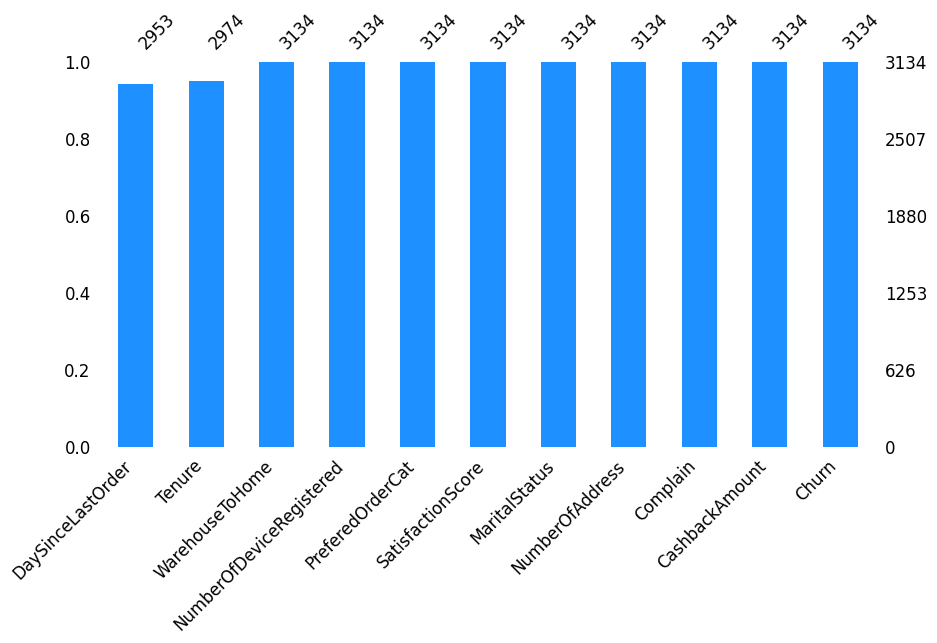

In [215]:
missingno.bar(df,color="dodgerblue", sort="ascending", figsize=(10,5), fontsize=12);

<Axes: >

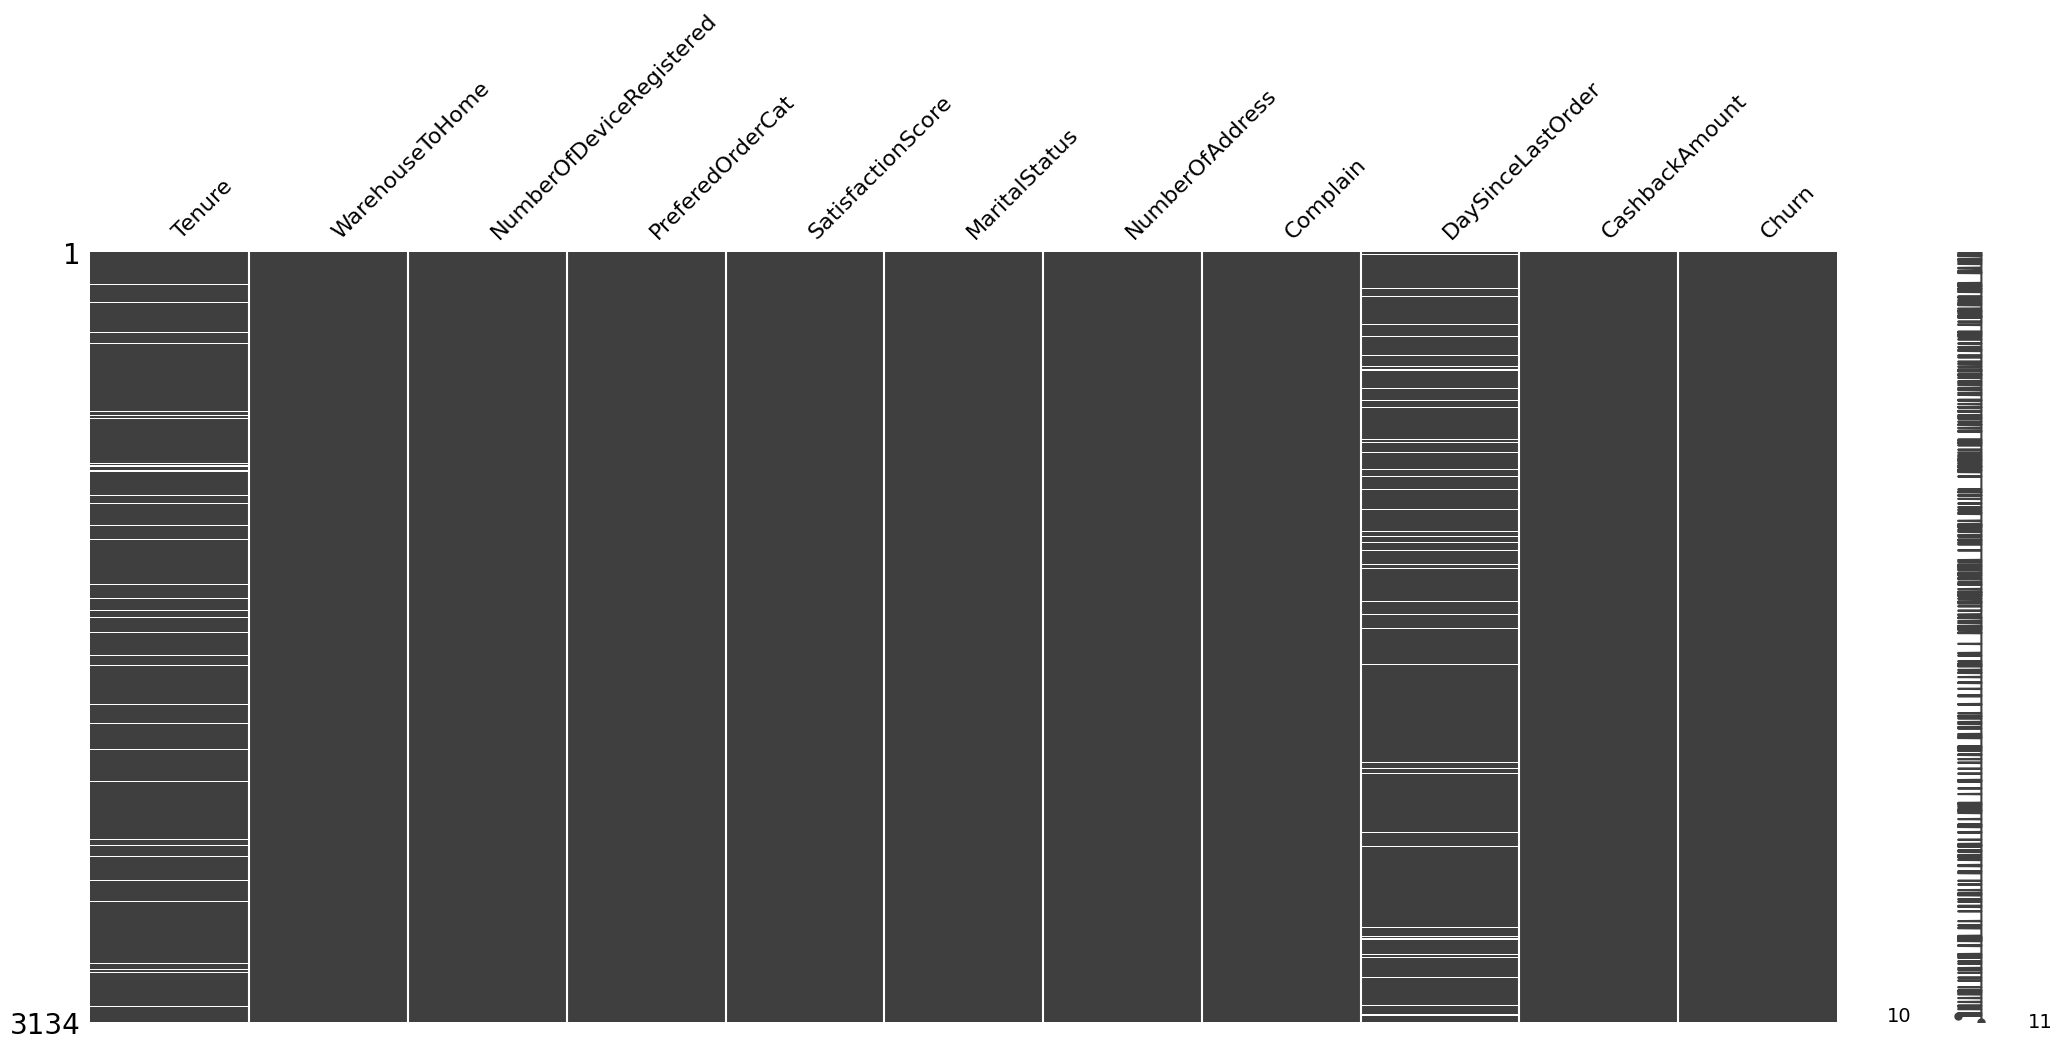

In [216]:
missingno.matrix(df)

Persebaran missing value tidak memiliki pola atau acak 

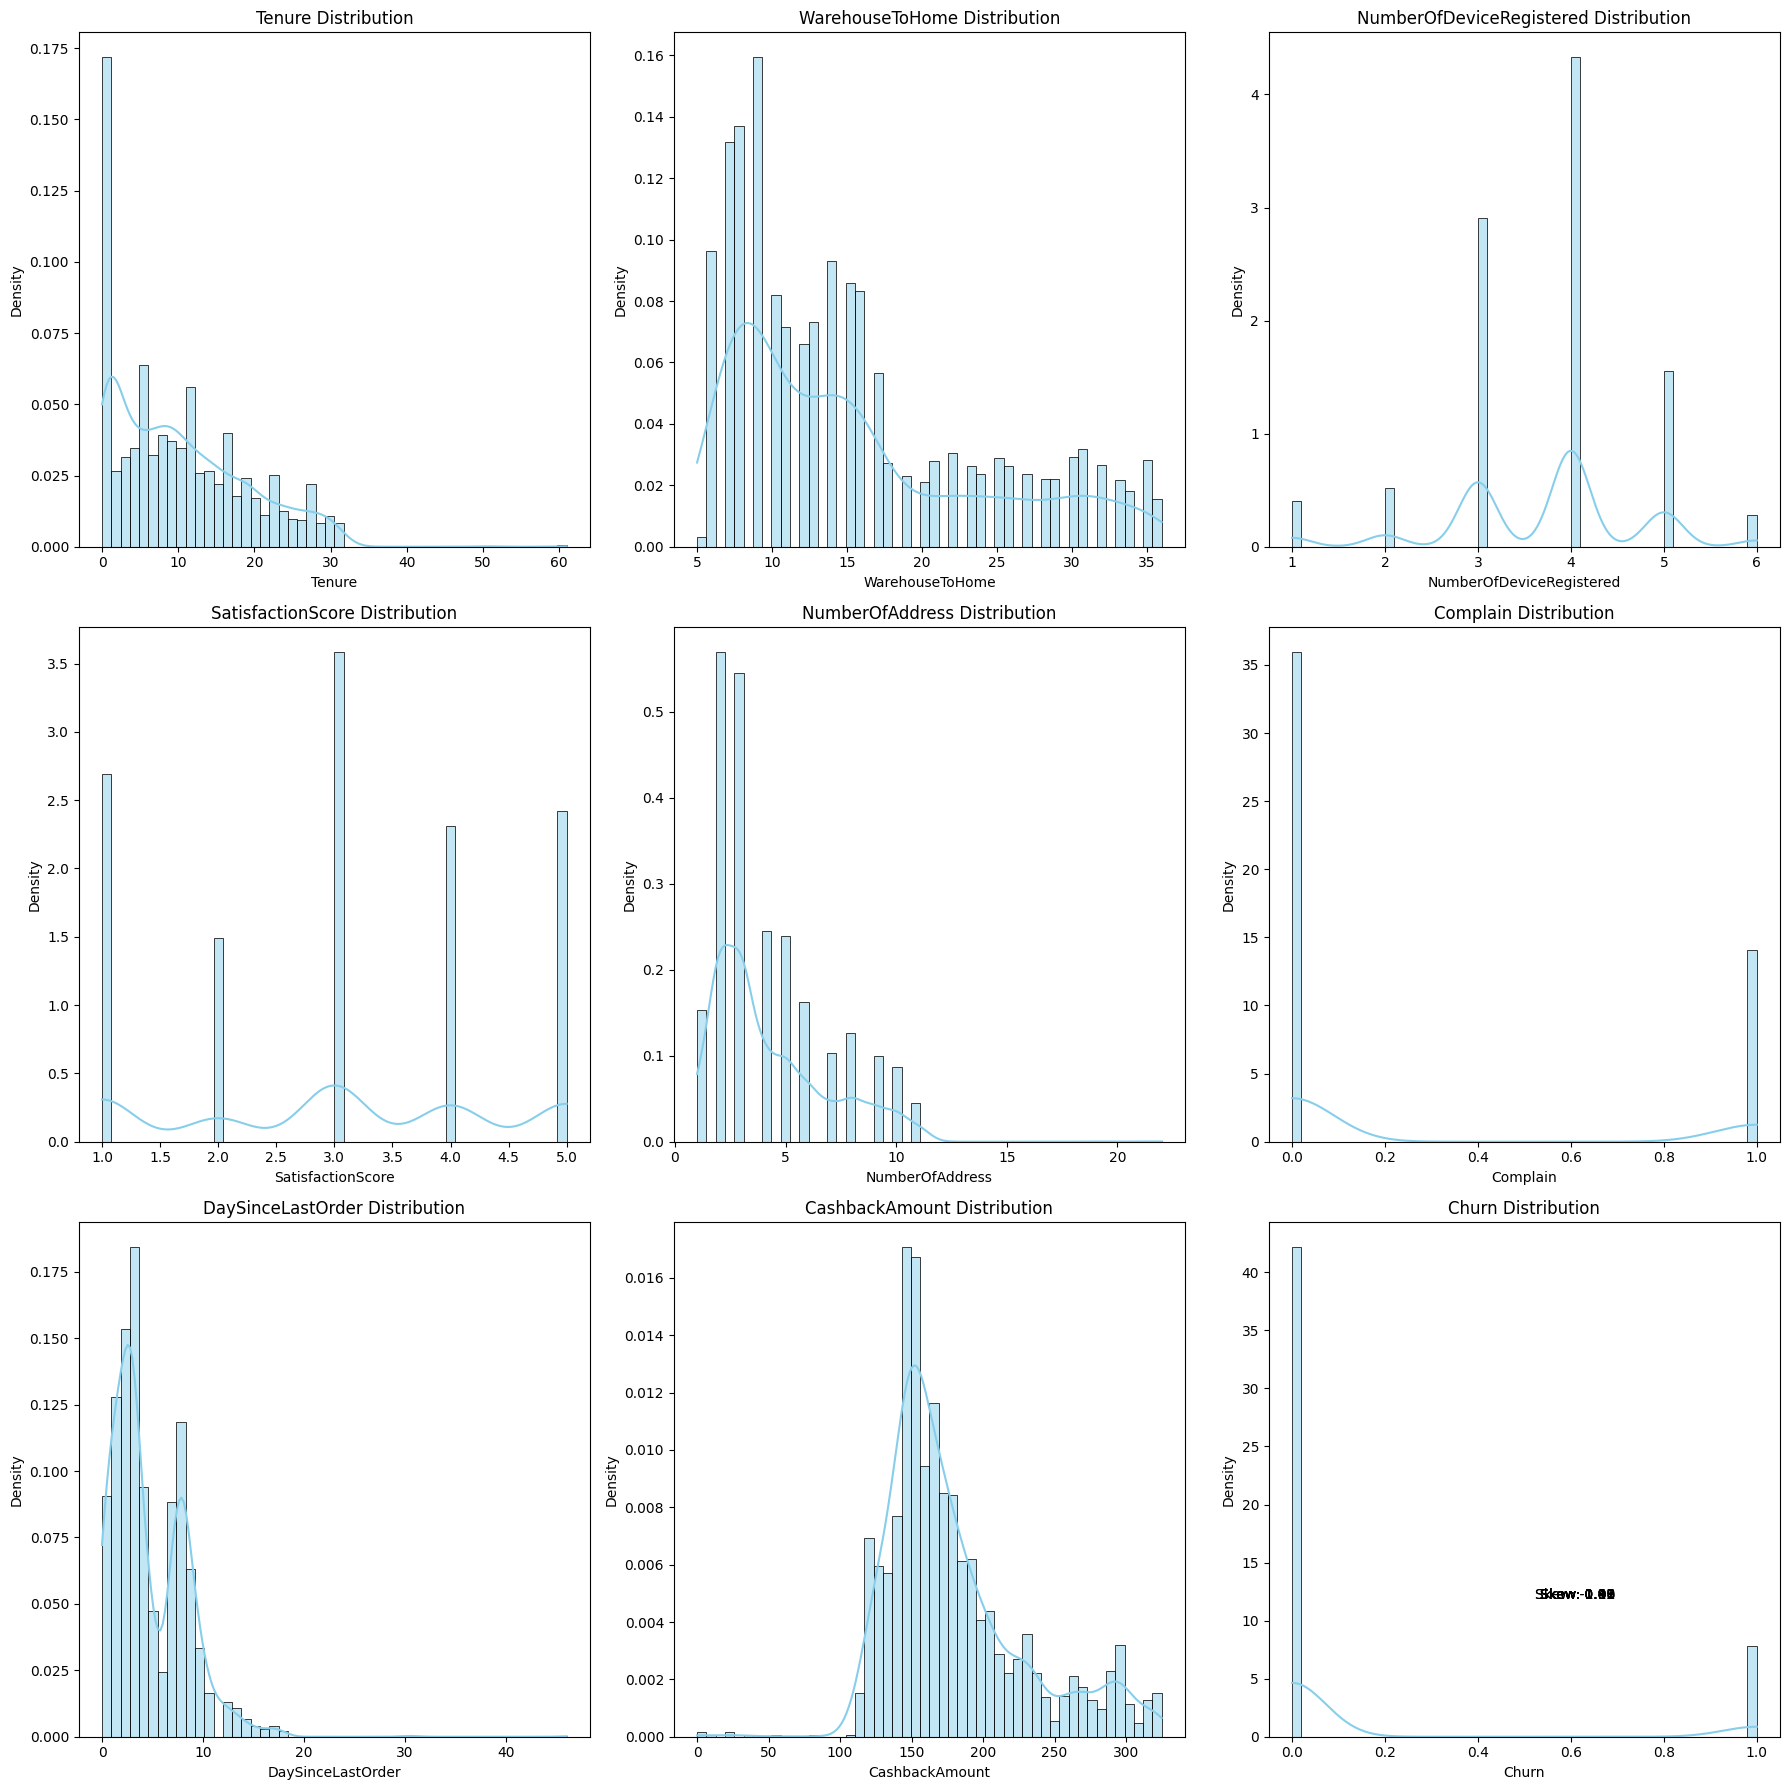

,Shapiro-Wilk p-value,D'Agostino p-value,Skewness,Skew Direction,Shapiro-Wilk Normal,D'Agostino Normal,Normally Distributed
Tenure,NaN,NaN,0.800559,Positive,False,False,False
WarehouseToHome,0.0,0.0,0.908442,Positive,False,False,False
NumberOfDeviceRegistered,0.0,0.0,-0.414801,Negative,False,False,False
SatisfactionScore,0.0,0.0,-0.087685,Negative,False,False,False
NumberOfAddress,0.0,0.0,1.116631,Positive,False,False,False
Complain,0.0,0.0,0.97606,Positive,False,False,False
DaySinceLastOrder,NaN,NaN,1.422236,Positive,False,False,False
CashbackAmount,0.0,0.0,1.063786,Positive,False,False,False
Churn,0.0,0.0,1.89666,Positive,False,False,False


In [212]:
from scipy import stats
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

num_cols = len(numerical_columns)
rows = (num_cols + 2) // 3
plt.figure(figsize=(18, 6 * rows))

normality_test_results = {}

for i, col in enumerate(numerical_columns):
    plt.subplot(rows, 3, i + 1)
    sns.histplot(df[col], kde=True, color="skyblue", stat="density", bins=50)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Density")
    
    shapiro_stat, shapiro_p = stats.shapiro(df[col])
    dagostino_stat, dagostino_p = stats.normaltest(df[col])
    
    skewness = df[col].skew()
    skew_text = f"Skew: {skewness:.2f}\n"
    
    normality_test_results[col] = {
        "Shapiro-Wilk p-value": shapiro_p,
        "D'Agostino p-value": dagostino_p,
        "Skewness": skewness,
        "Skew Direction": "Positive" if skewness > 0 else ("Negative" if skewness < 0 else "None"),
        "Shapiro-Wilk Normal": shapiro_p > 0.05,
        "D'Agostino Normal": dagostino_p > 0.05
    }
    
    plt.figtext(0.9, 0.1, skew_text, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

normality_results_df = pd.DataFrame(normality_test_results).T
normality_results_df["Normally Distributed"] = normality_results_df["Shapiro-Wilk Normal"] & normality_results_df["D'Agostino Normal"]
normality_results_df

Data Numerikal tidak terdistribusi normal maka pengisian missing value pada kolom Tenure dan DaySinceLastOrder menggunakan median.

#### Duplicated

In [7]:
print(f'Jumlah baris sebelum drop duplikat: {len(df)}')
print(f'Jumlah duplikat: {df.duplicated().sum()}')

df = df.drop_duplicates()

print(f'Jumlah baris setelah drop duplikat: {len(df)}')

Jumlah baris sebelum drop duplikat: 3941
Jumlah duplikat: 671
Jumlah baris setelah drop duplikat: 3270


#### Outlier

,Kolom,Min,Max,Lower Bound,Upper Bound,N Outlier,Outlier %
7,CashbackAmount,0.0,324.99,69.25,278.14,241,7.69
2,NumberOfDeviceRegistered,1.0,6.00,1.50,5.50,215,6.86
6,DaySinceLastOrder,0.0,46.00,-7.00,17.00,9,0.29
0,Tenure,0.0,61.00,-16.50,35.50,4,0.13
4,NumberOfAddress,1.0,22.00,-4.00,12.00,3,0.10
1,WarehouseToHome,5.0,36.00,-7.50,36.50,0,0.00
3,SatisfactionScore,1.0,5.00,-1.00,7.00,0,0.00
5,Complain,0.0,1.00,-1.50,2.50,0,0.00


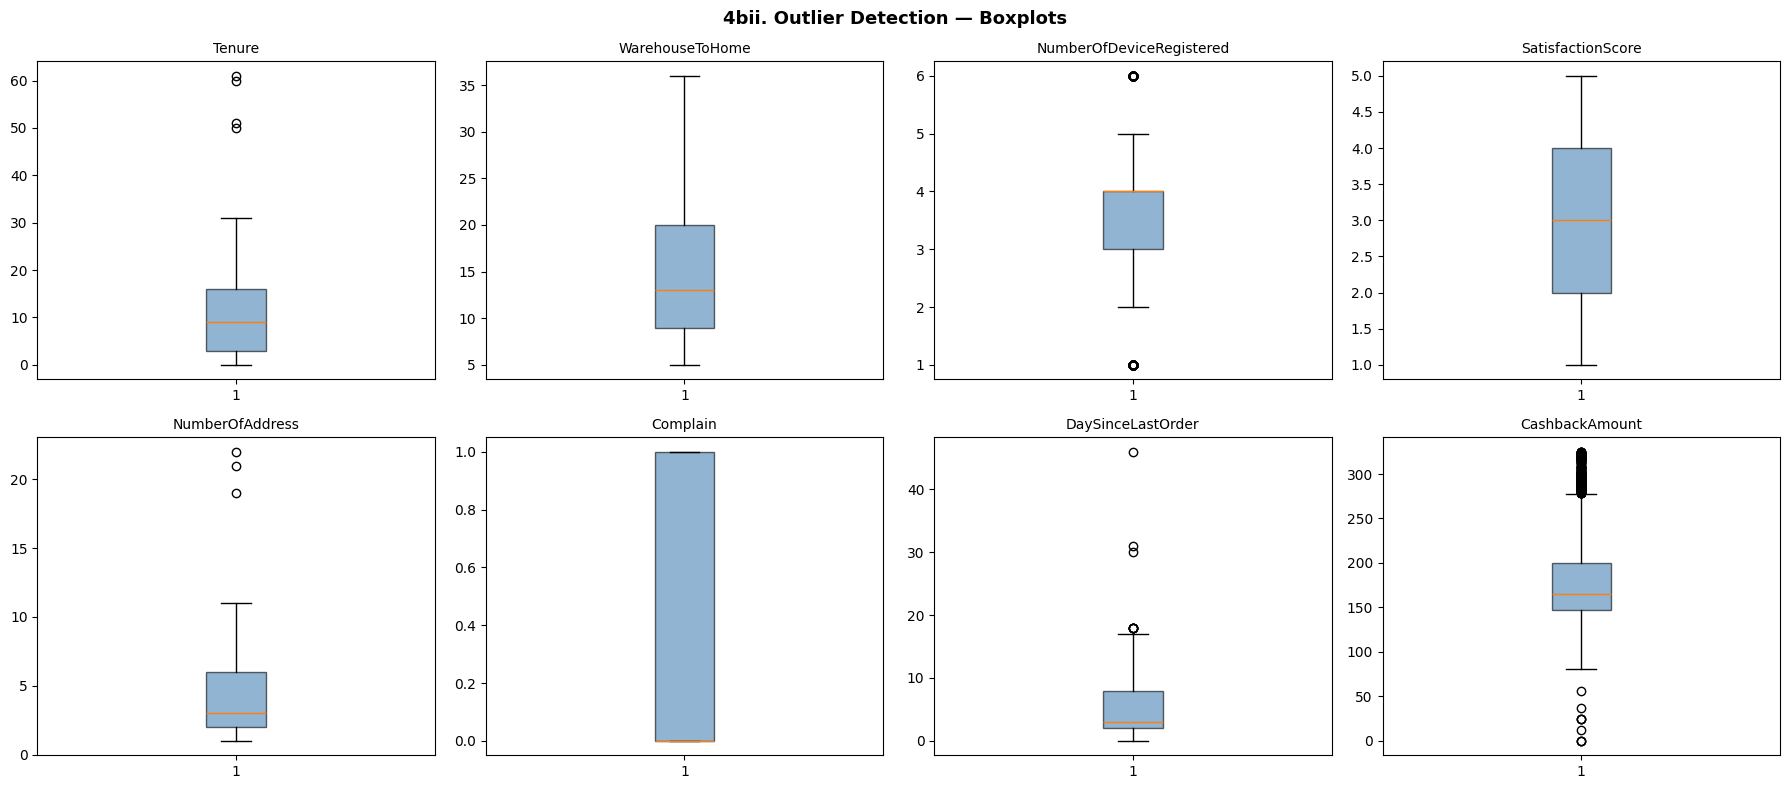

In [208]:
TARGET = 'Churn'
num_cols_eda = [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]

outlier_summary = []
for col in num_cols_eda:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo = Q1 - 1.5 * IQR
    hi = Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary.append({
        'Kolom': col, 'Min': df[col].min(), 'Max': df[col].max(),
        'Lower Bound': round(lo, 2), 'Upper Bound': round(hi, 2),
        'N Outlier': n_out, 'Outlier %': round(n_out/len(df)*100, 2)
    })

out_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
display(out_df)

# Boxplot
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols_eda):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('4bii. Outlier Detection — Boxplots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Outlier ini tetap dipertahankan karena representatif secara bisnis: 
- CashbackAmount & NumberOfDeviceRegistered memiliki outlier (8% dan 6.9%). Namun nilainya masih logis secara bisnis (cashback 0 bisa pelanggan baru,
  device terdaftar maks 6 masih wajar).
- DaySinceLastOrder max=46 hari: wajar untuk pelanggan semi-aktif.
Sedangkan WarehouseToHome max=127 km: hanya 1 outlier, sehingga bisa dihapus agar hasil tidak bias. 

In [8]:
Q1 = df['WarehouseToHome'].quantile(0.25)
Q3 = df['WarehouseToHome'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

outliers = df[df['WarehouseToHome'] > upper]
print(f'Jumlah outlier WarehouseToHome (> {upper:.1f} km): {len(outliers)} baris')

df = df[df['WarehouseToHome'] <= upper]
print(f'Jumlah baris setelah hapus outlier: {len(df)}')

Jumlah outlier WarehouseToHome (> 36.5 km): 1 baris
Jumlah baris setelah hapus outlier: 3134


#### Imbalanced

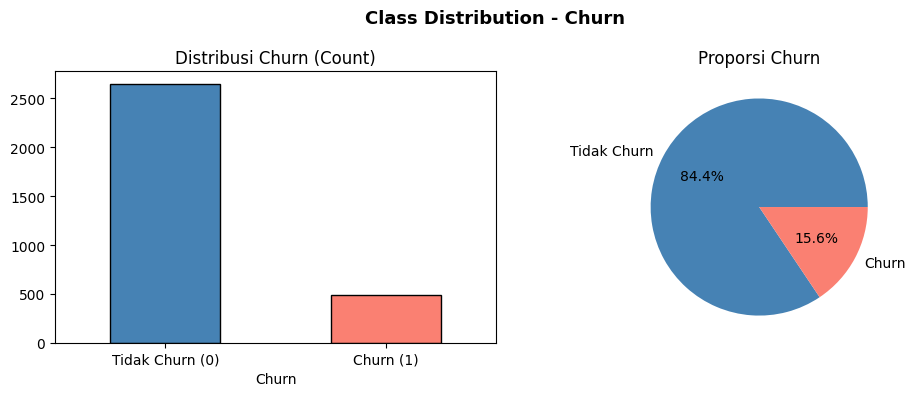

Churn
0    2645
1     489
Name: count, dtype: int64

Churn rate: 15.6%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Distribusi Churn (Count)')
axes[0].set_xticklabels(['Tidak Churn (0)', 'Churn (1)'], rotation=0)

df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                 colors=['steelblue', 'salmon'], labels=['Tidak Churn', 'Churn'])
axes[1].set_title('Proporsi Churn')
axes[1].set_ylabel('')

plt.suptitle('Class Distribution - Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean():.1%}")

Perlu adanya resampling tehnique untuk mengatasi data target minoritas yang imbalance (< 33%)

#### Feature Summary

,Dtype,Null Count,Null %,Unique,min,25%,50%,mean,75%,max
Tenure,float64,160,5.11,36,0.0,3.00,9.00,10.37,16.00,61.00
WarehouseToHome,float64,0,0.00,32,5.0,9.00,13.00,15.47,20.00,36.00
NumberOfDeviceRegistered,int64,0,0.00,6,1.0,3.00,4.00,3.70,4.00,6.00
PreferedOrderCat,object,0,0.00,6,NaN,NaN,NaN,NaN,NaN,NaN
SatisfactionScore,int64,0,0.00,5,1.0,2.00,3.00,3.02,4.00,5.00
MaritalStatus,object,0,0.00,3,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfAddress,int64,0,0.00,14,1.0,2.00,3.00,4.26,6.00,22.00
Complain,int64,0,0.00,2,0.0,0.00,0.00,0.28,1.00,1.00
DaySinceLastOrder,float64,181,5.78,22,0.0,2.00,3.00,4.64,8.00,46.00
CashbackAmount,float64,0,0.00,2244,0.0,147.58,165.53,179.70,199.81,324.99


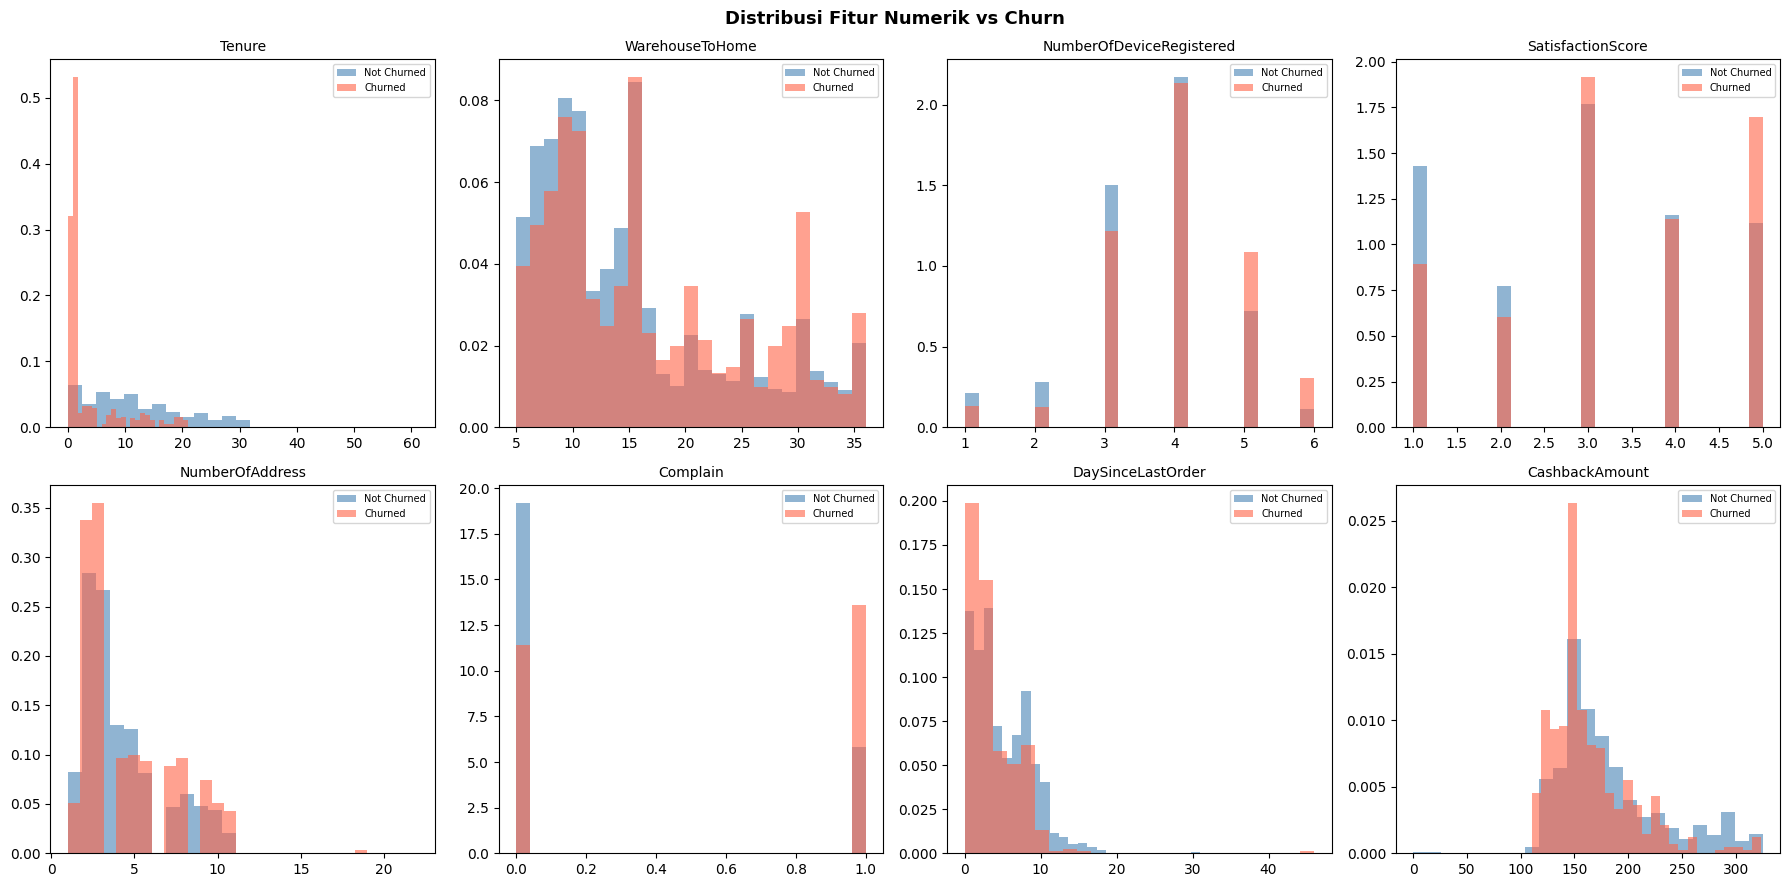

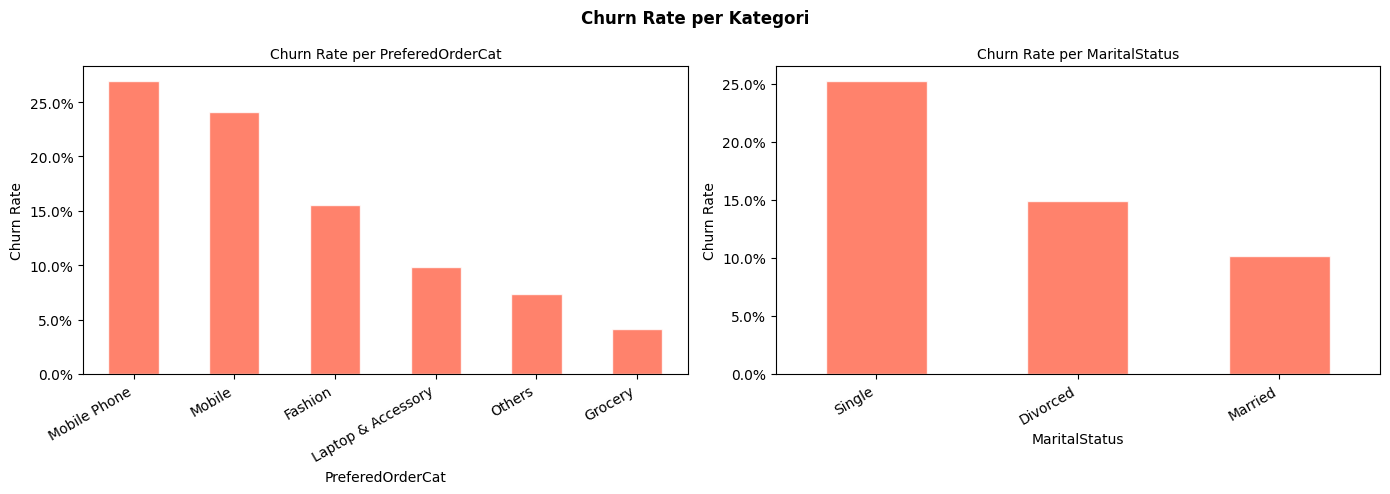

In [19]:
TARGET = 'Churn'
num_cols_eda = [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]
summary = pd.DataFrame({
    'Dtype'     : df.dtypes,
    'Null Count': df.isnull().sum(),
    'Null %'    : (df.isnull().sum() / len(df) * 100).round(2),
    'Unique'    : df.nunique(),
})
num_stats = df.describe().T[['min','25%','50%','mean','75%','max']].round(2)
summary = summary.join(num_stats)
display(summary)

# Distribusi fitur numerik vs Churn
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols_eda):
    for churn_val, color, label in zip([0,1], ['steelblue','tomato'],
                                        ['Not Churned','Churned']):
        axes[i].hist(df[df[TARGET]==churn_val][col].dropna(),
                     bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribusi fitur kategorik vs Churn
cat_cols_eda = df.select_dtypes(include='object').columns.tolist()
fig, axes = plt.subplots(1, len(cat_cols_eda), figsize=(14, 5))
if len(cat_cols_eda) == 1: axes = [axes]
for ax, col in zip(axes, cat_cols_eda):
    churn_rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='tomato', alpha=0.8, edgecolor='white')
    ax.set_title(f'Churn Rate per {col}', fontsize=10)
    ax.set_ylabel('Churn Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.suptitle('Churn Rate per Kategori', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [217]:
df.to_csv("data_clean.csv", index=False)

## Define X dan y

In [205]:
X = df.drop(columns=['Churn'])
y = df['Churn']

## Data Splitting

In [206]:
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.2,random_state= RANDOM_STATE)

## Feature Engineering

### Numerical dan Categorical Treatment

In [26]:
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()

print(f'Numerical ({len(num_features)}) : {num_features}')
print(f'Categorical ({len(cat_features)}) : {cat_features}')

Numerical (8) : ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']
Categorical (2) : ['PreferedOrderCat', 'MaritalStatus']


### Pipeline

In [27]:
# Pipeline DENGAN scaling (untuk Logreg & KNN)
num_pipe_scale = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Pipeline TANPA scaling (untuk tree-based models)
num_pipe_noscale = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical: most_frequent impute + OHE
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

### Feature Selection

  Percentile  50% → PR-AUC: 0.5793 ± 0.0534
  Percentile  60% → PR-AUC: 0.6019 ± 0.0596
  Percentile  70% → PR-AUC: 0.6207 ± 0.0564
  Percentile  80% → PR-AUC: 0.6315 ± 0.0596
  Percentile  90% → PR-AUC: 0.6728 ± 0.0486
  Percentile 100% → PR-AUC: 0.6726 ± 0.0489


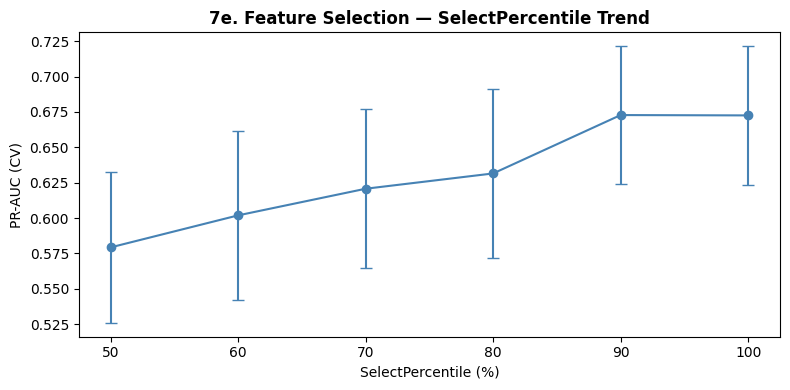


✅ Best percentile: 90%
   Jika peningkatan performa minimal antar percentile → gunakan 100% (semua fitur)


In [28]:
prep_for_sel = ColumnTransformer([
    ('num', num_pipe_scale, num_features),
    ('cat', cat_pipe,       cat_features),
])

percentiles = range(50, 110, 10)  # 50, 60, 70, 80, 90, 100
cv_sel = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

sel_results = []
for pct in percentiles:
    pipe_sel = Pipeline([
        ('prep'    , prep_for_sel),
        ('selector', SelectPercentile(f_classif, percentile=pct)),
        ('model'   , LogisticRegression(random_state=42, max_iter=1000))
    ])
    scores = cross_val_score(pipe_sel, X_train, y_train, cv=cv_sel,
                             scoring='average_precision', n_jobs=-1)
    sel_results.append({'Percentile': pct, 'PR_AUC': scores.mean(), 'Std': scores.std()})
    print(f'  Percentile {pct:3d}% → PR-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

sel_df = pd.DataFrame(sel_results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(sel_df['Percentile'], sel_df['PR_AUC'], yerr=sel_df['Std'],
            marker='o', color='steelblue', capsize=4)
ax.set_xlabel('SelectPercentile (%)')
ax.set_ylabel('PR-AUC (CV)')
ax.set_title('7e. Feature Selection — SelectPercentile Trend', fontweight='bold')
plt.tight_layout()
plt.show()

best_pct = sel_df.loc[sel_df['PR_AUC'].idxmax(), 'Percentile']
print(f'\n✅ Best percentile: {best_pct}%')
print('   Jika peningkatan performa minimal antar percentile → gunakan 100% (semua fitur)')

## Model Benchmarking

In [34]:
logreg = LogisticRegression()
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
xgb = XGBClassifier()
lgbm = lgb.LGBMClassifier()

In [29]:
preprocessor_scale = ColumnTransformer([
    ('num', num_pipe_scale, num_cols),
    ('cat', cat_pipe,       cat_cols)
])

preprocessor_noscale = ColumnTransformer([
    ('num', num_pipe_noscale, num_cols),
    ('cat', cat_pipe,         cat_cols)
])


In [38]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
import time
import pandas as pd

models_scale   = [logreg, knn]
models_noscale = [dt, rf, xgb, lgbm]
model_names_scale   = ['Logistic Regression', 'KNN']
model_names_noscale = ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']

scoring = {
    'average_precision': 'average_precision',
    'recall': 'recall',
    'accuracy': 'accuracy',
    'f1': 'f1',
    'precision': 'precision'
}

results = []

param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10]
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9]
    },
    'Decision Tree': {
        'model__max_depth': [3, 5, 10, None]
    },
    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, 10, None]
    },
    'XGBoost': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5],
        'model__learning_rate': [0.05, 0.1]
    },
    'LightGBM': {
        'model__n_estimators': [100, 200],
        'model__num_leaves': [31, 50],
        'model__learning_rate': [0.05, 0.1]
    }
}

for model_list, transformer, name_list in [
    (models_scale,   preprocessor_scale,   model_names_scale),
    (models_noscale, preprocessor_noscale, model_names_noscale)
]:
    for i, name in zip(model_list, name_list):
        
        skfold = StratifiedKFold(n_splits=5)

        estimator = Pipeline([
            ('preprocess', transformer),
            ('model', i)
        ])

        start_time = time.time()

        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grids[name],
            scoring=scoring,
            refit='average_precision',
            cv=skfold,
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        elapsed = time.time() - start_time

        best_idx = grid.best_index_

        results.append({
            'model': name,
            'best_params': grid.best_params_,
            'average_precision': grid.cv_results_['mean_test_average_precision'][best_idx],
            'recall': grid.cv_results_['mean_test_recall'][best_idx],
            'accuracy': grid.cv_results_['mean_test_accuracy'][best_idx],
            'f1': grid.cv_results_['mean_test_f1'][best_idx],
            'precision': grid.cv_results_['mean_test_precision'][best_idx],
            'time_elapsed_sec': elapsed
        })

pd.DataFrame(results).set_index('model').sort_values(
    by='average_precision', ascending=False
)

[LightGBM] [Info] Number of positive: 391, number of negative: 2116
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000389 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 389
[LightGBM] [Info] Number of data points in the train set: 2507, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.155963 -> initscore=-1.688575
[LightGBM] [Info] Start training from score -1.688575


,best_params,average_precision,recall,accuracy,f1,precision,time_elapsed_sec
model,,,,,,,
LightGBM,"{'model__learning_rate': 0.1, 'model__n_estima...",0.791223,0.670010,0.919420,0.721781,0.783869,11.128121
XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",0.779955,0.626550,0.915831,0.698468,0.791939,2.382443
Random Forest,"{'model__max_depth': None, 'model__n_estimator...",0.770500,0.585686,0.909849,0.669774,0.783261,9.196408
Logistic Regression,{'model__C': 1},0.663752,0.467835,0.884722,0.556044,0.690006,0.710704
Decision Tree,{'model__max_depth': 5},0.642236,0.532003,0.892299,0.606379,0.711703,0.676160
KNN,{'model__n_neighbors': 9},0.578755,0.291496,0.875948,0.423176,0.773214,0.847027


Berdasarkan Model Benchmarking (baseline) dengan menggunakan Logistic Regression, KNN, Random Forest, Decison Tree, XGBoost, dan LGBoost didapatkan dua model terbaik yaitu **LightGBM dan XGBoost**. Dua model ini memiliki nilai recall dan average_precision  paling baik diantara model lainnya. Namun, LightGBM memiliki waktu training yang lebih lambat dibanding XGBoost. Dua model ini akan dicompare dengan model resampling dan penalized untuk dilihat model yang memiliki performa terbaik untuk dijadikan best model dalam memprediksi churn. 

## Model Resampling 

In [39]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, NearMiss
import time
import pandas as pd

# =========================
# MODELS
# =========================
models_scale   = [logreg, knn]
models_noscale = [dt, rf, xgb, lgbm]

model_names_scale   = ['Logistic Regression', 'KNN']
model_names_noscale = ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']

# =========================
# SCORING
# =========================
scoring = {
    'average_precision': 'average_precision',
    'recall': 'recall',
    'accuracy': 'accuracy',
    'f1': 'f1',
    'precision': 'precision'
}

# =========================
# PARAM GRID
# =========================
param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10]
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9]
    },
    'Decision Tree': {
        'model__max_depth': [3, 5, 10, None]
    },
    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, 10, None]
    },
    'XGBoost': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5],
        'model__learning_rate': [0.05, 0.1]
    },
    'LightGBM': {
        'model__n_estimators': [100, 200],
        'model__num_leaves': [31, 50],
        'model__learning_rate': [0.05, 0.1]
    }
}

# =========================
# RESAMPLING STRATEGY
# =========================
resamplers = {
    "none": None,
    "smote": SMOTE(random_state=42),
    "ros": RandomOverSampler(random_state=42),
    "rus": RandomUnderSampler(random_state=42),
    "nearmiss": NearMiss()
}

# =========================
# RESULT CONTAINER
# =========================
results = []

# =========================
# LOOP
# =========================
for res_name, resampler in resamplers.items():
    
    for model_list, transformer, name_list in [
        (models_scale,   preprocessor_scale,   model_names_scale),
        (models_noscale, preprocessor_noscale, model_names_noscale)
    ]:
        
        for model, name in zip(model_list, name_list):
            
            skfold = StratifiedKFold(n_splits=5)

            steps = [
                ('preprocess', transformer)
            ]

            # 🔥 resampling masuk DI SINI
            if resampler is not None:
                steps.append(('resample', resampler))

            steps.append(('model', model))

            pipeline = Pipeline(steps)

            start_time = time.time()

            grid = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grids[name],
                scoring=scoring,
                refit='average_precision',
                cv=skfold,
                n_jobs=-1
            )

            grid.fit(X_train, y_train)

            elapsed = time.time() - start_time

            best_idx = grid.best_index_

            results.append({
                'resampling': res_name,
                'model': name,
                'best_params': grid.best_params_,
                'average_precision': grid.cv_results_['mean_test_average_precision'][best_idx],
                'recall': grid.cv_results_['mean_test_recall'][best_idx],
                'accuracy': grid.cv_results_['mean_test_accuracy'][best_idx],
                'f1': grid.cv_results_['mean_test_f1'][best_idx],
                'precision': grid.cv_results_['mean_test_precision'][best_idx],
                'time_elapsed_sec': elapsed
            })

# =========================
# RESULT TABLE
# =========================
df_results = pd.DataFrame(results).sort_values(
    by='average_precision', ascending=False
)

df_results

[LightGBM] [Info] Number of positive: 391, number of negative: 2116
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 389
[LightGBM] [Info] Number of data points in the train set: 2507, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.155963 -> initscore=-1.688575
[LightGBM] [Info] Start training from score -1.688575
[LightGBM] [Info] Number of positive: 2116, number of negative: 2116
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3662
[LightGBM] [Info] Number of data points in the train set: 4232, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] 

,resampling,model,best_params,average_precision,recall,accuracy,f1,precision,time_elapsed_sec
17,ros,LightGBM,"{'model__learning_rate': 0.1, 'model__n_estima...",0.793054,0.728984,0.917830,0.734289,0.741363,13.249979
11,smote,LightGBM,"{'model__learning_rate': 0.1, 'model__n_estima...",0.792529,0.675170,0.919023,0.722293,0.778246,16.003170
5,none,LightGBM,"{'model__learning_rate': 0.1, 'model__n_estima...",0.791223,0.670010,0.919420,0.721781,0.783869,23.644310
16,ros,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",0.782008,0.752029,0.906664,0.715170,0.682195,2.950006
4,none,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",0.779955,0.626550,0.915831,0.698468,0.791939,2.864025
3,none,Random Forest,"{'model__max_depth': None, 'model__n_estimator...",0.771690,0.590782,0.911842,0.676614,0.793158,8.027651
10,smote,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",0.770082,0.677799,0.918627,0.721708,0.773912,4.999077
15,ros,Random Forest,"{'model__max_depth': None, 'model__n_estimator...",0.767066,0.693054,0.919022,0.727525,0.766121,8.401151
9,smote,Random Forest,"{'model__max_depth': None, 'model__n_estimator...",0.738916,0.618858,0.907459,0.675490,0.744477,12.255566
22,rus,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",0.717648,0.846608,0.846016,0.633029,0.507253,2.639236


Berdasarkan Model dengan Resampling menggunakan SMOTE, NearMiss, RandomOverSampling dan RandomUnderSampling dengan pertimbangan matriks dan timeselapses dua model terbaik yaitu **ROS LightGBM dan ROS XGBoost**. Dua model ini memiliki nilai recall dan average_precision  paling baik diantara model lainnya. Namun, LightGBM memiliki waktu training yang lebih lambat dibanding XGBoost. Dua model ini akan dicompare dengan model baseline dan penalized untuk dilihat model yang memiliki performa terbaik untuk dijadikan best model dalam memprediksi churn. 

## Penalized 

In [40]:
# SCALE POS WEIGHT (for boosting)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# MODELS
models_scale   = [logreg, knn]
models_noscale = [dt, rf, xgb, lgbm]

model_names_scale   = ['Logistic Regression', 'KNN']
model_names_noscale = ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']

# =========================
# SCORING
# =========================
scoring = {
    'average_precision': 'average_precision',
    'recall': 'recall',
    'accuracy': 'accuracy',
    'f1': 'f1',
    'precision': 'precision'
}

# =========================
# PARAM GRID
# =========================
param_grids = {
    'Logistic Regression': {'model__C': [0.01, 0.1, 1, 10]},
    'KNN': {'model__n_neighbors': [3, 5, 7, 9]},
    'Decision Tree': {'model__max_depth': [3, 5, 10, None]},
    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, 10, None]
    },
    'XGBoost': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5],
        'model__learning_rate': [0.05, 0.1]
    },
    'LightGBM': {
        'model__n_estimators': [100, 200],
        'model__num_leaves': [31, 50],
        'model__learning_rate': [0.05, 0.1]
    }
}

# =========================
# UPDATED BOOSTING MODELS
# =========================
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=100,
    num_leaves=31,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# replace in list just to be safe
models_noscale = [dt, rf, xgb, lgbm]

# =========================
# RESULT CONTAINER
# =========================
results = []

# =========================
# MAIN LOOP (NO RESAMPLING)
# =========================
for model_list, transformer, name_list in [
    (models_scale, preprocessor_scale, model_names_scale),
    (models_noscale, preprocessor_noscale, model_names_noscale)
]:
    
    for model, name in zip(model_list, name_list):

        skfold = StratifiedKFold(n_splits=5)

        pipeline = Pipeline([
            ('preprocess', transformer),
            ('model', model)
        ])

        start_time = time.time()

        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            scoring=scoring,
            refit='average_precision',
            cv=skfold,
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        elapsed = time.time() - start_time
        best_idx = grid.best_index_

        results.append({
            'model': name,
            'best_params': grid.best_params_,
            'average_precision': grid.cv_results_['mean_test_average_precision'][best_idx],
            'recall': grid.cv_results_['mean_test_recall'][best_idx],
            'accuracy': grid.cv_results_['mean_test_accuracy'][best_idx],
            'f1': grid.cv_results_['mean_test_f1'][best_idx],
            'precision': grid.cv_results_['mean_test_precision'][best_idx],
            'time_sec': elapsed
        })

# =========================
# FINAL TABLE
# =========================
df_results = pd.DataFrame(results).sort_values(
    by='average_precision',
    ascending=False
)

df_results

[LightGBM] [Info] Number of positive: 391, number of negative: 2116
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 389
[LightGBM] [Info] Number of data points in the train set: 2507, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.155963 -> initscore=-1.688575
[LightGBM] [Info] Start training from score -1.688575


,model,best_params,average_precision,recall,accuracy,f1,precision,time_sec
5,LightGBM,"{'model__learning_rate': 0.1, 'model__n_estima...",0.792965,0.723791,0.920215,0.739362,0.757975,25.640909
3,Random Forest,"{'model__max_depth': None, 'model__n_estimator...",0.777904,0.601006,0.914633,0.687378,0.804096,7.554992
4,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",0.776908,0.767413,0.911451,0.729760,0.696188,2.834321
0,Logistic Regression,{'model__C': 1},0.663752,0.467835,0.884722,0.556044,0.690006,11.582109
2,Decision Tree,{'model__max_depth': 5},0.642236,0.532003,0.892299,0.606379,0.711703,0.692973
1,KNN,{'model__n_neighbors': 9},0.578755,0.291496,0.875948,0.423176,0.773214,0.720733


Berdasarkan Model dengan Penalized dengan pertimbangan matriks dan timeselapses dua model terbaik yaitu **XGBoost dan LightGBM**. Dua model ini memiliki nilai recall dan average_precision  paling baik diantara model lainnya. Namun, LightGBM memiliki waktu training yang lebih lambat dibanding XGBoost. Dua model ini akan dicompare dengan model baseline dan resamplinguntuk dilihat model yang memiliki performa terbaik untuk dijadikan best model dalam memprediksi churn. 

## Validasi Model Terbaik 

Validasi model terbaik dilakukan untuk melihat model mana yang paling bagus diantara model baseline, diberikan perlakuan resampling dan penalized untuk nantinya akan dihyperparameter tuning supaya mendapatkan hasil yang maksimal.


  None | XGBoost
              precision    recall  f1-score   support

    No Churn       0.92      0.97      0.94       529
       Churn       0.74      0.53      0.62        98

    accuracy                           0.90       627
   macro avg       0.83      0.75      0.78       627
weighted avg       0.89      0.90      0.89       627


  None | LightGBM
              precision    recall  f1-score   support

    No Churn       0.93      0.97      0.95       529
       Churn       0.78      0.61      0.69        98

    accuracy                           0.91       627
   macro avg       0.86      0.79      0.82       627
weighted avg       0.91      0.91      0.91       627


  ROS | XGBoost
              precision    recall  f1-score   support

    No Churn       0.94      0.91      0.92       529
       Churn       0.58      0.70      0.64        98

    accuracy                           0.88       627
   macro avg       0.76      0.81      0.78       627
weighted avg       0

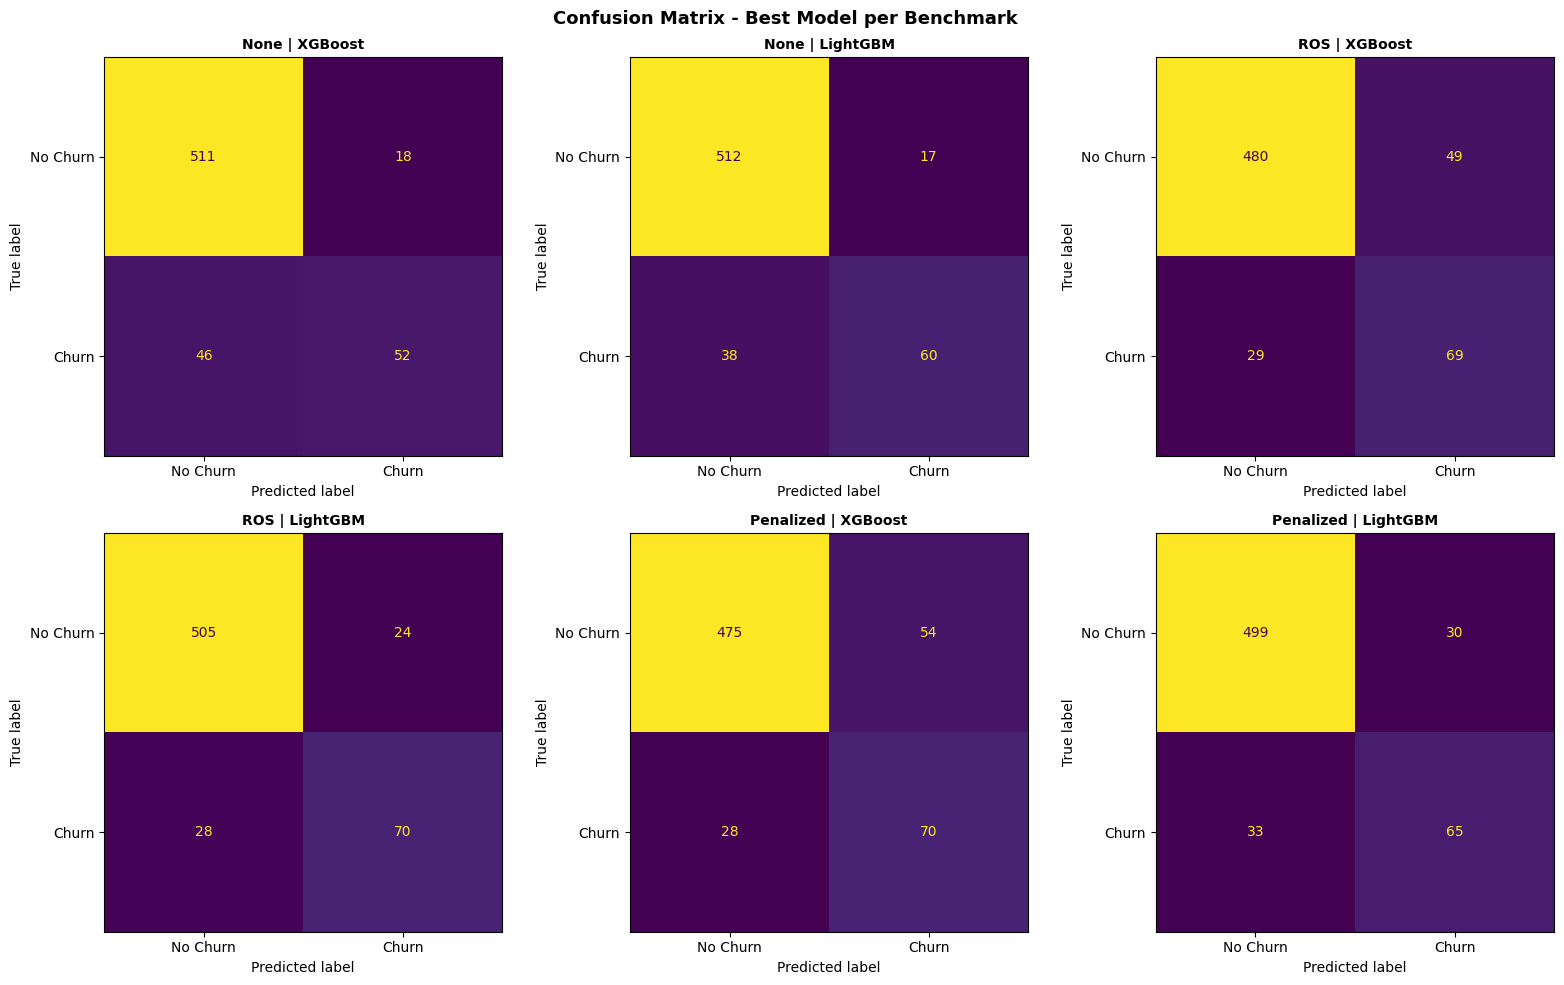

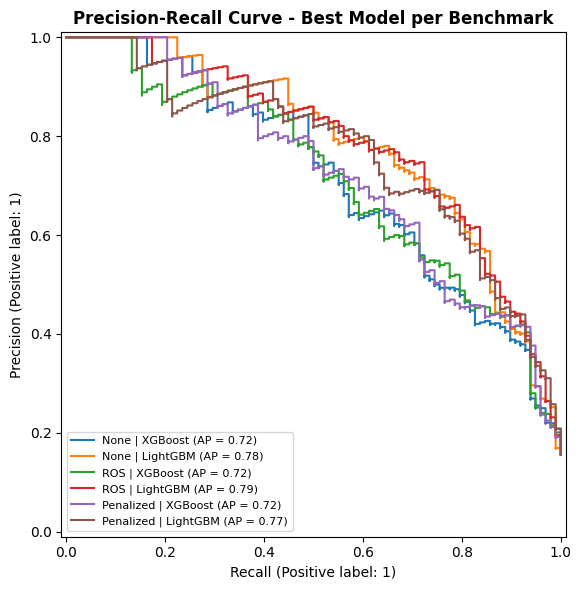

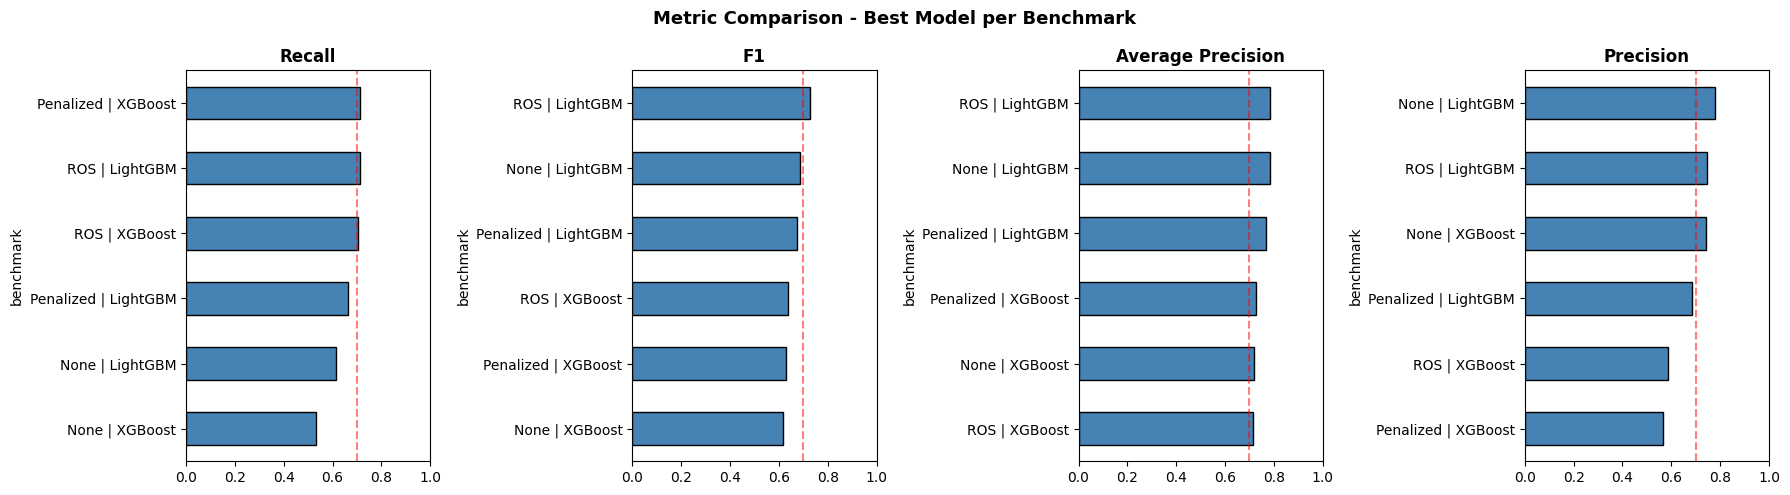

In [207]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.metrics import (classification_report, confusion_matrix,
                             average_precision_score, recall_score,
                             accuracy_score, f1_score, precision_score,
                             ConfusionMatrixDisplay, RocCurveDisplay)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ─────────────────────────────────────────────────────────────
# 1. DEFINISI BEST MODEL DARI SETIAP BENCHMARK
# ─────────────────────────────────────────────────────────────

best_models = {

    # ── BENCHMARK 1: No Resampling ──────────────────────────
    # XGBoost: Recall 0.767, Time 2.83s (best recall + fastest)
    "None | XGBoost": Pipeline([
        ('preprocess', preprocessor_noscale),
        ("model", XGBClassifier(
            learning_rate=0.1,
            max_depth=3,          # sesuaikan dengan best_params kamu
            n_estimators=200,     # sesuaikan dengan best_params kamu
            eval_metric="logloss",
            random_state=42
        ))
    ]),

    # LightGBM: Avg Precision tertinggi (0.793), F1 terbaik (0.739)
    "None | LightGBM": Pipeline([
        ('preprocess', preprocessor_noscale),
        ("model", LGBMClassifier(
            learning_rate=0.1,
            n_estimators=200,     # sesuaikan dengan best_params kamu
            verbose=-1,
            random_state=42
        ))
    ]),

    # ── BENCHMARK 2: Resampling (ROS) ───────────────────────
    # ROS + XGBoost: Recall 0.752, Time 2.95s (sweet spot)
    "ROS | XGBoost": ImbPipeline([
        ('preprocess', preprocessor_noscale),
        ("resample", RandomOverSampler(random_state=42)),
        ("model", XGBClassifier(
            learning_rate=0.1,
            max_depth=3,          # sesuaikan dengan best_params kamu
            n_estimators=200,     # sesuaikan dengan best_params kamu
            eval_metric="logloss",
            random_state=42
        ))
    ]),

    # ROS + LightGBM: Avg Precision terbaik (0.793), F1 terbaik (0.734)
    "ROS | LightGBM": ImbPipeline([
        ('preprocess', preprocessor_noscale),
        ("resample", RandomOverSampler(random_state=42)),
        ("model", LGBMClassifier(
            learning_rate=0.1,
            n_estimators=200,     # sesuaikan dengan best_params kamu
            verbose=-1,
            random_state=42
        ))
    ]),

    # ── BENCHMARK 3: Penalized (Class Weight) ───────────────
    # XGBoost Penalized: scale_pos_weight untuk imbalanced
    "Penalized | XGBoost": Pipeline([
        ('preprocess', preprocessor_noscale),
        ("model", XGBClassifier(
            learning_rate=0.1,
            max_depth=3,          # sesuaikan dengan best_params kamu
            n_estimators=200,     # sesuaikan dengan best_params kamu
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            eval_metric="logloss",
            random_state=42
        ))
    ]),

    # LightGBM Penalized: class_weight='balanced'
    "Penalized | LightGBM": Pipeline([
        ('preprocess', preprocessor_noscale),
        ("model", LGBMClassifier(
            learning_rate=0.1,
            n_estimators=200,     # sesuaikan dengan best_params kamu
            class_weight="balanced",
            verbose=-1,
            random_state=42
        ))
    ]),
}

# ─────────────────────────────────────────────────────────────
# 2. TRAIN & EVALUATE DI TEST SET
# ─────────────────────────────────────────────────────────────

results = []

for name, pipeline in best_models.items():
    start = time.time()
    pipeline.fit(X_train, y_train)
    elapsed = time.time() - start

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "benchmark"        : name,
        "average_precision": average_precision_score(y_test, y_prob),
        "recall"           : recall_score(y_test, y_pred),
        "accuracy"         : accuracy_score(y_test, y_pred),
        "f1"               : f1_score(y_test, y_pred),
        "precision"        : precision_score(y_test, y_pred),
        "time_sec"         : round(elapsed, 3),
    })

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# ─────────────────────────────────────────────────────────────
# 3. SUMMARY TABLE
# ─────────────────────────────────────────────────────────────

df_results = pd.DataFrame(results).set_index("benchmark")
df_results = df_results.sort_values("recall", ascending=False)

print("\n📊 Summary - Best Model per Benchmark (Test Set):")
print(df_results.round(4))

# ─────────────────────────────────────────────────────────────
# 4. CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────

n = len(best_models)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, pipeline) in enumerate(best_models.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=axes[idx], colorbar=False)
    axes[idx].set_title(name, fontsize=10, fontweight='bold')

plt.suptitle("Confusion Matrix - Best Model per Benchmark", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# 5. PR AUC CURVE
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(9, 6))

for name, pipeline in best_models.items():
    PrecisionRecallDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        ax=ax,
        name=name
    )

ax.set_title("Precision-Recall Curve - Best Model per Benchmark", 
             fontsize=12, fontweight='bold')

plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()
# ─────────────────────────────────────────────────────────────
# 6. BAR CHART PERBANDINGAN METRIK
# ─────────────────────────────────────────────────────────────

metrics = ["recall", "f1", "average_precision", "precision"]
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    df_results[metric].sort_values().plot(
        kind="barh", ax=ax, color="steelblue", edgecolor="black"
    )
    ax.set_title(metric.replace("_", " ").title(), fontweight='bold')
    ax.set_xlim(0, 1)
    ax.axvline(0.7, color='red', linestyle='--', alpha=0.5, label='0.7 threshold')

plt.suptitle("Metric Comparison - Best Model per Benchmark", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Berdasarkan tabel diatas model terbaik dengan pertimbangan matriks dan timeselapse adalah **ROS- LightGBM** dan selanjutkan akan di hyperparameter tuning untuk dilihat parameter terbaiknya sehingga hasil prediksi akan maksimal. 

# Hyperparameter Tuning

In [58]:
from imblearn.pipeline import Pipeline   # ✅ BUKAN sklearn
ros = RandomOverSampler(random_state=42)

estimator=Pipeline([
    ('oversampling',ros),
    ('preprocess', preprocessor_noscale),
    ('model', LGBMClassifier())
])


In [61]:
from scipy.stats import randint, uniform
hyperparam_space = [{
    'model__max_bin': randint(200, 400),
    'model__num_leaves': randint(20, 60),
    'model__min_data_in_leaf': randint(10, 50),
    'model__num_iterations': randint(50, 200),
    'model__learning_rate': uniform(0.03, 0.1),
    'model__random_state': [42]
}]

default hyperparameter LGBM => max_bin = 255, num_leaves = 31, min_data_in_leaf = 20, num_iterations = 100, learning_rate = 0.1

In [64]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

random_search = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=hyperparam_space,
    n_iter=50,  # bisa kamu ubah (misalnya 10–50)
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42
)

In [65]:
random_search.fit(X_train, y_train)

print(random_search.best_score_)
print(random_search.best_params_)

0.7934122573279393
{'model__learning_rate': np.float64(0.09807054515547668), 'model__max_bin': 252, 'model__min_data_in_leaf': 35, 'model__num_iterations': 117, 'model__num_leaves': 30, 'model__random_state': 42}


Berdasarkan hasil tuning didapatkan parameter **ROS- LightGBM** terbaik yaitu {'model__learning_rate': np.float64(0.09807054515547668), 'model__max_bin': 252, 'model__min_data_in_leaf': 35, 'model__num_iterations': 117, 'model__num_leaves': 30, 'model__random_state': 42}

## Uji ke Data Test

In [67]:
# ─────────────────────────────────────────────────────────────
# 1. DEFINISI BEST MODEL DARI SETIAP BENCHMARK
# ─────────────────────────────────────────────────────────────

best_models = {

    # ── BENCHMARK 1: No Resampling ──────────────────────────
    # XGBoost: Recall 0.767, Time 2.83s (best recall + fastest)
    "None | XGBoost": Pipeline([
        ('preprocess', preprocessor_noscale),
        ("model", XGBClassifier(
            learning_rate=0.1,
            max_depth=3,          # sesuaikan dengan best_params kamu
            n_estimators=200,     # sesuaikan dengan best_params kamu
            eval_metric="logloss",
            random_state=42
        ))
    ]),

    # LightGBM: Avg Precision tertinggi (0.793), F1 terbaik (0.739)
    "None | LightGBM": Pipeline([
        ('preprocess', preprocessor_noscale),
        ("model", LGBMClassifier(
            learning_rate=0.1,
            n_estimators=200,     # sesuaikan dengan best_params kamu
            verbose=-1,
            random_state=42
        ))
    ]),

    # ── BENCHMARK 2: Resampling (ROS) ───────────────────────
    # ROS + XGBoost: Recall 0.752, Time 2.95s (sweet spot)
    "ROS | XGBoost": ImbPipeline([
        ('preprocess', preprocessor_noscale),
        ("resample", RandomOverSampler(random_state=42)),
        ("model", XGBClassifier(
            learning_rate=0.1,
            max_depth=3,          # sesuaikan dengan best_params kamu
            n_estimators=200,     # sesuaikan dengan best_params kamu
            eval_metric="logloss",
            random_state=42
        ))
    ]),

    # ROS + LightGBM: Avg Precision terbaik (0.793), F1 terbaik (0.734)
    "ROS | LightGBM": ImbPipeline([
        ('preprocess', preprocessor_noscale),
        ("resample", RandomOverSampler(random_state=42)),
        ("model", LGBMClassifier(
            learning_rate=0.1,
            n_estimators=200,     # sesuaikan dengan best_params kamu
            verbose=-1,
            random_state=42
        ))
    ]),

    # ── BENCHMARK 3: Penalized (Class Weight) ───────────────
    # XGBoost Penalized: scale_pos_weight untuk imbalanced
    "Penalized | XGBoost": Pipeline([
        ('preprocess', preprocessor_noscale),
        ("model", XGBClassifier(
            learning_rate=0.1,
            max_depth=3,          # sesuaikan dengan best_params kamu
            n_estimators=200,     # sesuaikan dengan best_params kamu
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            eval_metric="logloss",
            random_state=42
        ))
    ]),

    # LightGBM Penalized: class_weight='balanced'
    "Penalized | LightGBM": Pipeline([
        ('preprocess', preprocessor_noscale),
        ("model", LGBMClassifier(
            learning_rate=0.1,
            n_estimators=200,     # sesuaikan dengan best_params kamu
            class_weight="balanced",
            verbose=-1,
            random_state=42
        ))
    ]),
    # ── BENCHMARK 4: Hypertuning ───────────────    
    # ROS + LightGBM
    "ROS | LightGBM Hypertuning": ImbPipeline([
        ('preprocess', preprocessor_noscale),
        ("resample", RandomOverSampler(random_state=42)),
        ("model", LGBMClassifier(
              learning_rate=0.09807054515547668,
        max_bin=252,
        min_data_in_leaf=35,
        n_estimators=117,
        num_leaves=30,
        verbose=-1,
        random_state=42
        ))
    ]),

}

# ─────────────────────────────────────────────────────────────
# 2. TRAIN & EVALUATE DI TEST SET
# ─────────────────────────────────────────────────────────────

results = []

for name, pipeline in best_models.items():
    start = time.time()
    pipeline.fit(X_train, y_train)
    elapsed = time.time() - start

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "benchmark"        : name,
        "average_precision": average_precision_score(y_test, y_prob),
        "recall"           : recall_score(y_test, y_pred),
        "accuracy"         : accuracy_score(y_test, y_pred),
        "f1"               : f1_score(y_test, y_pred),
        "precision"        : precision_score(y_test, y_pred),
        "time_sec"         : round(elapsed, 3),
    })

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# ─────────────────────────────────────────────────────────────
# 3. SUMMARY TABLE
# ─────────────────────────────────────────────────────────────

df_results = pd.DataFrame(results).set_index("benchmark")
df_results = df_results.sort_values("recall", ascending=False)

print("\n📊 Summary - Best Model per Benchmark (Test Set):")
print(df_results.round(4))



  None | XGBoost
              precision    recall  f1-score   support

    No Churn       0.92      0.97      0.94       529
       Churn       0.74      0.53      0.62        98

    accuracy                           0.90       627
   macro avg       0.83      0.75      0.78       627
weighted avg       0.89      0.90      0.89       627


  None | LightGBM
              precision    recall  f1-score   support

    No Churn       0.93      0.97      0.95       529
       Churn       0.78      0.61      0.69        98

    accuracy                           0.91       627
   macro avg       0.86      0.79      0.82       627
weighted avg       0.91      0.91      0.91       627


  ROS | XGBoost
              precision    recall  f1-score   support

    No Churn       0.94      0.91      0.92       529
       Churn       0.58      0.70      0.64        98

    accuracy                           0.88       627
   macro avg       0.76      0.81      0.78       627
weighted avg       0

Berdasarkan hasil uji ke data test dengan melihat hasil dari matrik yang digunakan dan timeselapse didapatkan bahwa **ROS | LightGBM Hypertuning** memiliki performa terbaik dibanding model lain sehingga dapat dijadikan sebagai best model dalam prediksi e-commerce churn. 

In [154]:
best_model = best_models["ROS | LightGBM Hypertuning"]
best_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('resample', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [155]:
estimator_baseline = Pipeline([
    ('preprocess', preprocessor_noscale),
    ('resample', RandomOverSampler(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])
estimator.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('resample', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [156]:
y_proba = best_model.predict_proba(X_test)[:, 1]


In [157]:
y_pred_default = estimator.predict(X_test)
y_pred_proba_default = estimator.predict_proba(X_test)

y_pred_tuned = best_model.predict(X_test)
y_pred_proba_tuned = best_model.predict_proba(X_test)

pr_auc_default = average_precision_score(y_test, y_pred_proba_default[:, 1])
pr_auc_tuned = average_precision_score(y_test, y_pred_proba_tuned[:, 1])

print(f"PR AUC Score Default LGBM : {pr_auc_default:.4f}")
print(f"PR AUC Score Tuned LGBM   : {pr_auc_tuned:.4f}")

PR AUC Score Default LGBM : 0.7450
PR AUC Score Tuned LGBM   : 0.7450


### Untuk meningkatkan hasil recall, perlu penyesuaian treshold sehingga nilai recall dapat naik untuk menangkap lebih banyak customer yang akan churn. 

In [159]:
thresholds = np.arange(0.1, 0.9, 0.01)

best_t = 0
best_recall = 0

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    rec = recall_score(y_test, y_pred)

    if rec > best_recall:
        best_recall = rec
        best_t = t

print("Best Threshold:", best_t)
print("Best Recall:", best_recall)

Best Threshold: 0.1
Best Recall: 0.8775510204081632


In [160]:
y_pred_final = (y_proba >= best_t).astype(int)

In [161]:
print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.97      0.82      0.89       529
           1       0.48      0.88      0.62        98

    accuracy                           0.83       627
   macro avg       0.72      0.85      0.75       627
weighted avg       0.90      0.83      0.85       627

[[434  95]
 [ 12  86]]


In [164]:
report_default = classification_report(y_test, y_pred_default)
report_tuned = classification_report(y_test, y_pred_final)

print('Classification Report Default LGBM : \n', report_default)
print('Classification Report Tuned LGBM : \n', report_tuned)

Classification Report Default LGBM : 
               precision    recall  f1-score   support

           0       0.95      0.94      0.95       529
           1       0.71      0.73      0.72        98

    accuracy                           0.91       627
   macro avg       0.83      0.84      0.83       627
weighted avg       0.91      0.91      0.91       627

Classification Report Tuned LGBM : 
               precision    recall  f1-score   support

           0       0.97      0.82      0.89       529
           1       0.48      0.88      0.62        98

    accuracy                           0.83       627
   macro avg       0.72      0.85      0.75       627
weighted avg       0.90      0.83      0.85       627



Berdasarkan tabel terlihat setelah dilakukan penyesuaian threshold, model mampu menangkap lebih banyak pelanggan yang akan churn. Hal ini bisa dibuktikan dengan adanya peningkatan recall pada kelas 1 yang awalnya 0.73 menjadi 0.88, akan tetapi harus mengorbankan nilai F1-score atau false alarm akan lebih banyak dibanding sebelumnya. 

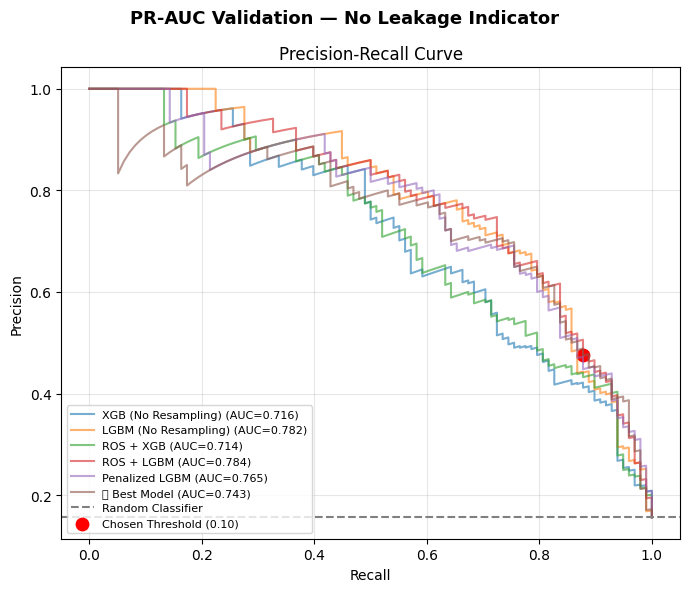

In [187]:
fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('PR-AUC Validation — No Leakage Indicator', fontsize=13, fontweight='bold')

trained_pipelines = best_models
best_tuned_pipeline = trained_pipelines['ROS | LightGBM Hypertuning']
# =========================
# KEY MODELS
# =========================
key_models = {
    'XGB (No Resampling)': (trained_pipelines.get('None | XGBoost'), X_test, y_test),
    'LGBM (No Resampling)': (trained_pipelines.get('None | LightGBM'), X_test, y_test),
    'ROS + XGB': (trained_pipelines.get('ROS | XGBoost'), X_test, y_test),
    'ROS + LGBM': (trained_pipelines.get('ROS | LightGBM'), X_test, y_test),
    'Penalized LGBM': (trained_pipelines.get('Penalized | LightGBM'), X_test, y_test),
    '🔥 Best Model': (trained_pipelines.get('ROS | LightGBM Hypertuning'), X_test, y_test),
}


# =========================
# PLOT PR CURVES
# =========================
for name, (pipe, Xt, yt) in key_models.items():
    if pipe is None:
        continue
        
    yp = pipe.predict_proba(Xt)[:, 1]
    prec_c, rec_c, _ = precision_recall_curve(yt, yp)
    pr = auc(rec_c, prec_c)
    
    # highlight best model
    if name == 'RF Tuned':
        ax.plot(rec_c, prec_c, linewidth=2.5, label=f'{name} (AUC={pr:.3f})')
    else:
        ax.plot(rec_c, prec_c, alpha=0.6, label=f'{name} (AUC={pr:.3f})')

# =========================
# BASELINE (RANDOM)
# =========================
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', label='Random Classifier')

# =========================
# ADD THRESHOLD POINT (BEST MODEL)
# =========================
best_pipe = best_tuned_pipeline
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

prec_c, rec_c, thr = precision_recall_curve(y_test, y_proba_best)

# cari titik threshold terdekat dengan best_t
idx = np.argmin(np.abs(thr - best_t))

best_prec = prec_c[idx]
best_rec = rec_c[idx]

ax.scatter(best_rec, best_prec, color='red', s=80,
           label=f'Chosen Threshold ({best_t:.2f})')

# =========================
# LABELING
# =========================
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')

ax.legend(loc='lower left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

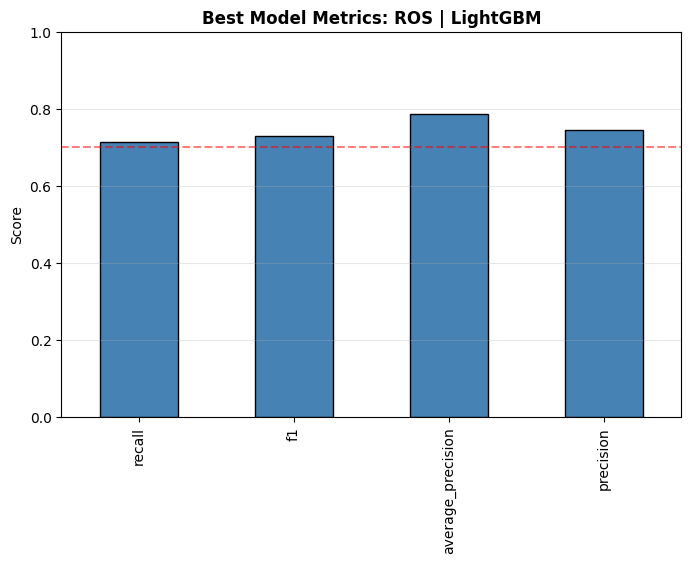

In [190]:
# ─────────────────────────────────────────────
# 1. BEST MODEL SELECTION
# ─────────────────────────────────────────────

best_row = df_results.loc[df_results["average_precision"].idxmax()]
metrics = ["recall", "f1", "average_precision", "precision"]

best_values = best_row[metrics]

# ─────────────────────────────────────────────
# 2. THRESHOLD-BASED PREDICTION (BEST MODEL)
# ─────────────────────────────────────────────

best_model = best_tuned_pipeline

y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = y_pred_final = (y_proba >= best_t).astype(int)

# ─────────────────────────────────────────────
# 3. PLOT METRICS
# ─────────────────────────────────────────────

best_values.plot(
    kind="bar",
    figsize=(8, 5),
    color="steelblue",
    edgecolor="black"
)

plt.title(f"Best Model Metrics: {best_row.name}", fontweight='bold')
plt.ylim(0, 1)
plt.axhline(0.7, color='red', linestyle='--', alpha=0.5)
plt.ylabel("Score")
plt.grid(axis='y', alpha=0.3)
plt.show()

## Check Model

### Cost Benefit Analysis

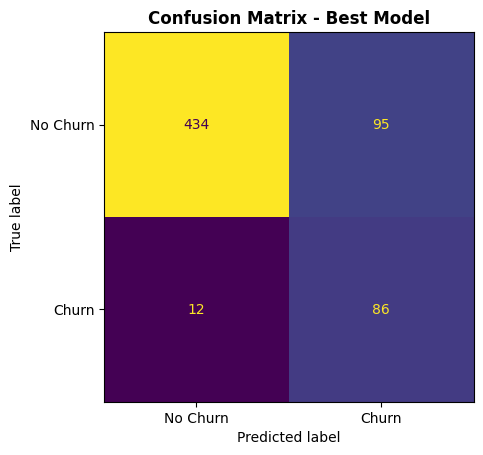

In [178]:
y_pred = y_pred_final = (y_proba >= best_t).astype(int)

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"])

disp.plot(colorbar=False)
plt.title("Confusion Matrix - Best Model", fontsize=12, fontweight='bold')
plt.show()

In [188]:
TN, FP, FN, TP = cm.ravel()
print(f"\n  TP (Benar prediksi Churn)   : {TP}")
print(f"  FP (Salah prediksi Churn)   : {FP}")
print(f"  TN (Benar prediksi No-Churn): {TN}")
print(f"  FN (Salah — Miss Churn)     : {FN}")

print(f"\n  Recall    : {TP/(TP+FN):.4f}")
print(f"  Precision : {TP/(TP+FP):.4f}")


  TP (Benar prediksi Churn)   : 86
  FP (Salah prediksi Churn)   : 95
  TN (Benar prediksi No-Churn): 434
  FN (Salah — Miss Churn)     : 12

  Recall    : 0.8776
  Precision : 0.4751


In [189]:
# Assumptions (business-driven)
avg_customer_revenue = 500_000    # IDR — rata-rata revenue/pelanggan/tahun
retention_cost = 75_000          # IDR — biaya voucher/outreach per pelanggan
success_rate_retention = 0.60    # 60% retention berhasil setelah intervensi

# Scenario WITHOUT model (reactive)
total_churners_test = TP + FN
lost_revenue_no_model = total_churners_test * avg_customer_revenue

# Scenario WITH model
# TP: identified, intervene → 60% retained
revenue_saved = TP * success_rate_retention * avg_customer_revenue
cost_intervention_TP = TP * retention_cost
cost_intervention_FP = FP * retention_cost  # wasted on non-churners
total_cost = cost_intervention_TP + cost_intervention_FP
net_benefit = revenue_saved - total_cost

print(f"\n  Asumsi:")
print(f"    Rata-rata revenue/pelanggan/tahun : Rp {avg_customer_revenue:,.0f}")
print(f"    Biaya intervensi (voucher/outreach): Rp {retention_cost:,.0f}/pelanggan")
print(f"    Success rate retensi setelah intervensi: {success_rate_retention*100:.0f}%")

print(f"\n  Tanpa Model (Reaktif):")
print(f"    Churn yang tidak tertangani: {total_churners_test}")
print(f"    Revenue yang hilang: Rp {lost_revenue_no_model:,.0f}")

print(f"\n  Dengan Model:")
print(f"    TP (Churn terdeteksi)  : {TP} → {int(TP*success_rate_retention)} berhasil dipertahankan")
print(f"    Revenue diselamatkan   : Rp {revenue_saved:,.0f}")
print(f"    Biaya total intervensi : Rp {total_cost:,.0f}")
print(f"    Net Benefit            : Rp {net_benefit:,.0f}")
print(f"    ROI Model              : {net_benefit/total_cost*100:.1f}%")
print(f"    Efisiensi vs No-Model  : Hemat Rp {revenue_saved-total_cost:,.0f}")

pct_improvement = (net_benefit / lost_revenue_no_model) * 100
print(f"\n  → Model dapat mengurangi kerugian revenue sebesar {pct_improvement:.1f}% dibanding tanpa model!")



  Asumsi:
    Rata-rata revenue/pelanggan/tahun : Rp 500,000
    Biaya intervensi (voucher/outreach): Rp 75,000/pelanggan
    Success rate retensi setelah intervensi: 60%

  Tanpa Model (Reaktif):
    Churn yang tidak tertangani: 98
    Revenue yang hilang: Rp 49,000,000

  Dengan Model:
    TP (Churn terdeteksi)  : 86 → 51 berhasil dipertahankan
    Revenue diselamatkan   : Rp 25,800,000
    Biaya total intervensi : Rp 13,575,000
    Net Benefit            : Rp 12,225,000
    ROI Model              : 90.1%
    Efisiensi vs No-Model  : Hemat Rp 12,225,000

  → Model dapat mengurangi kerugian revenue sebesar 24.9% dibanding tanpa model!


### eXplainable Model 

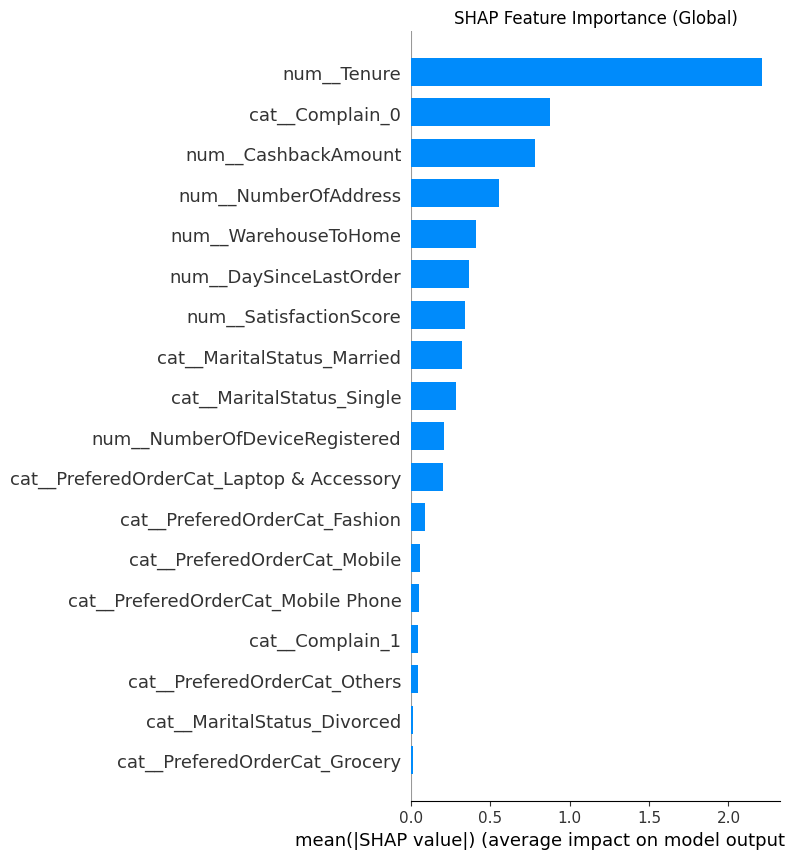

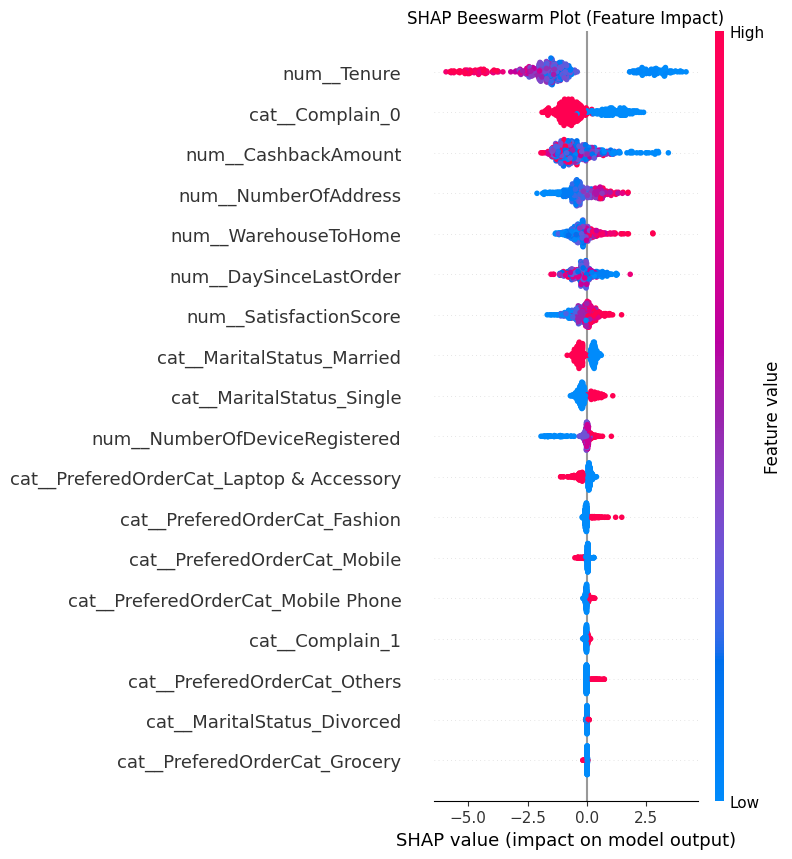

📌 SHAP Insight Summary:
- Feature dengan SHAP tertinggi paling mempengaruhi churn
- Nilai merah = fitur tinggi
- Nilai biru = fitur rendah
- Titik ke kanan → meningkatkan churn probability
- Titik ke kiri → menurunkan churn probability


In [194]:
import shap
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 1. SET BEST MODEL
# ─────────────────────────────────────────────

estimator = best_tuned_pipeline
prep = estimator.named_steps['preprocess']
model = estimator.named_steps['model']

# ─────────────────────────────────────────────
# 2. TRANSFORM TEST DATA
# ─────────────────────────────────────────────

X_test_transformed = prep.transform(x_test)

# convert sparse → dense (if needed)
if scipy.sparse.issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

# ─────────────────────────────────────────────
# 3. FEATURE NAMES (SAFE VERSION)
# ─────────────────────────────────────────────

feat_names = prep.get_feature_names_out()

# ─────────────────────────────────────────────
# 4. SAMPLE DATA (FAST SHAP)
# ─────────────────────────────────────────────

X_sample = X_test_transformed[:500].copy()

# ─────────────────────────────────────────────
# 5. SHAP EXPLAINER (TREE MODEL)
# ─────────────────────────────────────────────

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# ─────────────────────────────────────────────
# 6. SHAP BAR PLOT (GLOBAL IMPORTANCE)
# ─────────────────────────────────────────────

plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feat_names,
    plot_type='bar',
    show=False
)

plt.title("SHAP Feature Importance (Global)")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 7. SHAP BEESWARM PLOT (DETAILED INSIGHT)
# ─────────────────────────────────────────────

plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feat_names,
    show=False
)

plt.title("SHAP Beeswarm Plot (Feature Impact)")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 8. INSIGHT SUMMARY
# ─────────────────────────────────────────────

print("📌 SHAP Insight Summary:")
print("- Feature dengan SHAP tertinggi paling mempengaruhi churn")
print("- Nilai merah = fitur tinggi")
print("- Nilai biru = fitur rendah")
print("- Titik ke kanan → meningkatkan churn probability")
print("- Titik ke kiri → menurunkan churn probability")

**5 faktor teratas yang mempengaruhi churn :**
- Nilai tenure rendah
- Customer yang pernah complain
- Cashback Rendah
- Lama tidak belanja
- Banyak device atau Address

**Recommendation :**
- Early retention strategi dengan onboarding yang bagus supaya customer baru merasa diberikan perhatian lebih
- Peningkatan customer service
- Targeted cashback untuk at-risk users atau yang akan churn
- Meningkatkan recency dengan winback campaign
- Melakukan segmentasi "high flexibility users"


### Interpretable Model 

##### Coefficient Logistic Regression

In [170]:
# Fit model
lr_pipe.fit(X_train, y_train)

# ─────────────────────────────────────────────
# Ambil preprocess + model
# ─────────────────────────────────────────────
prep = lr_pipe.named_steps['prep']
model = lr_pipe.named_steps['model']

# ─────────────────────────────────────────────
# Ambil feature names langsung dari preprocessing
# ─────────────────────────────────────────────
feature_names = prep.get_feature_names_out()

# ─────────────────────────────────────────────
# Ambil coefficient
# ─────────────────────────────────────────────
coef = model.coef_[0]

# ─────────────────────────────────────────────
# Cek panjang (debug safety)
# ─────────────────────────────────────────────
print(len(coef), len(feature_names))

# ─────────────────────────────────────────────
# Feature importance
# ─────────────────────────────────────────────
feat_importance = pd.Series(coef, index=feature_names)\
                    .sort_values(key=abs, ascending=False)

print(feat_importance.head(10))

18 18
cat__PreferedOrderCat_Others                2.275153
num__Tenure                                -1.657135
cat__PreferedOrderCat_Laptop & Accessory   -1.538779
cat__PreferedOrderCat_Mobile Phone         -0.879984
cat__Complain_1                             0.858058
cat__Complain_0                            -0.840227
num__CashbackAmount                        -0.709723
cat__PreferedOrderCat_Mobile               -0.690148
cat__MaritalStatus_Single                   0.590504
cat__PreferedOrderCat_Grocery               0.535996
dtype: float64


**Interpretasi Hasil:**

**Faktor yang meningkatkan Churn:**
- cat__PreferedOrderCat_Others : Customer dengan kategori order "Others" paling kuat risk churnnya karena tidak memiliki preferensi yang jelas
- cat__Complain_1 : Customer yang pernah komplain cenderung churn
- cat__MaritalStatus_Single : Sedikit lebih rawan churn 
- cat__PreferedOrderCat_Grocery : Sedikit meningkatkan churn
  
**Faktor yang tidak meningkatkan Churn:**
- num__Tenure : Semakin lama customer maka semakin kecil kemungkinan churn            
- cat__PreferedOrderCat_Laptop & Accessory : Customer ini stabil karena biasanya high-intent buyer cebderung lebih loyal
- cat__PreferedOrderCat_Mobile Phone : Customer dengan pembelian Mobile Phone cenderung stay karena mobile phone selalu diminati dan produk baru terus bermunculan
- cat__Complain_0 : Customer yang tidak komplain lebih loyal
- num__CashbackAmount : Cashback yang tinggi mengurangi churn
- cat__PreferedOrderCat_Mobile : Customer dengan pembelian Mobile cenderung stay karena mobile selalu diminati dan produk baru terus bermunculan


### Plot Tree : Feature Importances

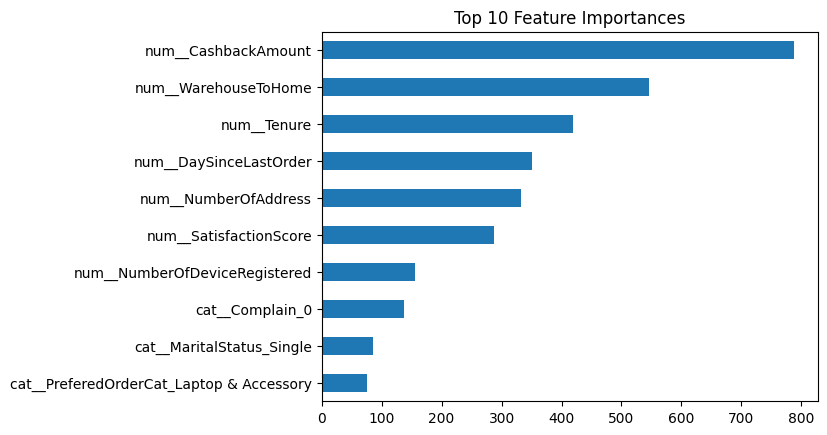

In [192]:
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

model = best_model.named_steps['model']

coef1 = pd.Series(
    model.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(10)

coef1.plot(kind='barh', title='Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

Berdasarkan hasil diatas feature yang paling berpengaruh adalah CashbackAmount dan paling tidak berpengaruh adalah cat_PreferedOrderCat_Laptop & Accessory

# Kesimpulan dan Rekomendasi

## Kesimpulan 

- Berdasarkan tabel diatas terlihat bahwa terdapat dua model yang memiliki performa yang bagus berdasarkan matrik yang digunakan yaitu LightGBM dan XGBoost baik dalam baseline atau diberikan perlakuan dengan resampling dan penalized. Pemilihan model ini lebih mementingkan recall tetapi tetap memperhatikan matriks lainnya dan juga waktu trainingnya. Matriks recall penting karena tujuan dalam model ini adalah ingin menangkap sebanyak mungkin False Negative atau gagal memprediksi customer yang churn sehingga tidak kehilangan pelanggan karena biaya mencari pelanggan baru lebih mahal dibanding mempertahankan pelanggan lama. 

- Berdasarkan tabel diatas model terbaik adalah **ROS | LightGBM Hypertuning** yang merupakan model hasil oversampling untuk mengatasi imbalance pada data target. Setelah mendapatkan model terbaik untuk meningkatkan performa maka diperlukan hypertuning parameter dengan hasil  {'model__learning_rate': np.float64(0.09807054515547668), 'model__max_bin': 252, 'model__min_data_in_leaf': 35, 'model__num_iterations': 117, 'model__num_leaves': 30, 'model__random_state': 42}. Hal ini terbukti dengan peningkatan Recall dari 0,7143 menjadi 0,7347

## Rekomendasi

### Rekomendasi Data 

Performa model dapat meningkat jika terdapat penambahan fitur: <br>
   • RFM Metrics (Recency, Frequency, Monetary) — sangat relevan <br>
   • CustomerSupportInteractions — frekuensi hubungi CS <br>
   • AppEngagementScore — seberapa aktif buka app <br>
   • PromotionResponseRate — respon terhadap promo/voucher <br>
   • ReturnRate — frekuensi return produk <br>
   • PaymentMethod — metode pembayaran (kartu kredit = loyalitas lebih tinggi) <br>
   • Geolocation / Region — pola churn berbeda per wilayah<br>
  <br>
Fitur-fitur ini diprediksi dapat mendorong Recall ke >90% <br>

### Rekomendasi Model 

- Feature Engineering: tambah fitur interaksi (Tenure×Complain, CashbackAmount÷DaySinceLastOrder)
- Mencoba menggunakan model terbaik kedua yaitu XGBoost untuk lihat apakah lebih baik performamcenya setelah dituning parameternya

### Rekomendasi Bisnis 

#### User 

- Tim CRM/Retention: menggunakan output daily untuk prioritas outreach
- Marketing Analyst: membuat segmentasi kampanye voucher/cashback
- Customer Success Manager: monitor high-risk accounts

#### Maintenance dan Retraining

- Periode retraining: SETIAP 3 BULAN (quarterly)
- Trigger: jika PR-AUC turun >5% dari baseline, langsung retrain
- Monitor konsep drift: distribusi fitur (Tenure, CashbackAmount)
- Data baru minimal 1.000 transaksi baru sebelum retrain

#### Penggunaan Model

- Kapan: Setiap akhir bulan (batch prediction — 1× sebulan)
- Frekuensi: 1 kali sebulan untuk scoring seluruh database
- Volume input: Seluruh pelanggan aktif (~50.000–500.000 data)
- Output: Skor risiko churn (0–1) + segmentasi (Low/Medium/High Risk)

#### Justifikasi Kepada Investor 

Dengan mengimplementasikan model prediksi churn ini, ShopNest diproyeksikan dapat:
- Mengurangi churn rate dari 17% → 10–12% dalam 6 bulan pertama
- Menghemat ~{pct_improvement:.0f}% dari potensi kerugian revenue akibat churn
- ROI investasi model: 24.9% dalam 1 siklus kampanye
- Meningkatkan LTV pelanggan rata-rata 15–25% melalui retensi proaktif
- Menekan CAC efektif — retensi 5× lebih murah dari akuisisi baru

"Dengan model ini, setiap 1 rupiah yang diinvestasikan untuk retensi menghasilkan 0.9× nilai balik dalam revenue yang diselamatkan.""

## Save Best Model

In [71]:
best_model = best_models["ROS | LightGBM Hypertuning"]

In [72]:
import joblib

best_model = best_models["ROS | LightGBM Hypertuning"]
best_model.fit(X_train, y_train)

# save ke file
joblib.dump(best_model, "lgbm_best_model.pkl")

['lgbm_best_model.pkl']